# 15. Factor Investing and Fama French Allocation

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import warnings

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_yfinance_panel
from quantfinlab.plotting.curves import set_plot_style
from quantfinlab.portfolio.selection import build_strategy_summary, build_trade_table, calc_drawdown
warnings.filterwarnings("ignore")
set_plot_style()
pd.options.display.float_format = "{:.4f}".format

In [2]:
data_path = Path("../data")
etf_path = data_path / "ETF_data.csv"
factor_file = data_path / "F-F_Research_Data_5_Factors_2x3.csv"
industry_file = data_path / "12_Industry_Portfolios.csv"

sector_tickers = [
    "XLB", "XLE", "XLF", "XLI", "XLK",
    "XLP", "XLU", "XLV", "XLY",
    "IYR", "IYZ",
]

cash_ticker = "SHY"
benchmark_ticker = "SPY"

In [3]:
tickers = sector_tickers + [cash_ticker, benchmark_ticker]
prices = load_yfinance_panel(
    etf_path,
    fields=("close",),
    tickers=tickers,
    start="1999-01-01",
)["close"].ffill(limit=3)
prices = prices.reindex(columns=tickers)

coverage = pd.DataFrame(
    {
        "ticker": prices.columns,
        "first date": [prices[c].first_valid_index() for c in prices.columns],
        "last date": [prices[c].last_valid_index() for c in prices.columns],
        "observations": prices.notna().sum().values,
    }
)
display(coverage)

,ticker,first date,last date,observations
0,XLB,1999-01-04,2026-05-22,7020
1,XLE,1999-01-04,2026-05-22,7020
2,XLF,1999-01-04,2026-05-22,7020
3,XLI,1999-01-04,2026-05-22,7020
4,XLK,1999-01-04,2026-05-22,7020
5,XLP,1999-01-04,2026-05-22,7020
6,XLU,1999-01-04,2026-05-22,7020
7,XLV,1999-01-04,2026-05-22,7020
8,XLY,1999-01-04,2026-05-22,7020
9,IYR,2000-06-19,2026-05-22,6647


In [4]:
monthly_prices = prices.resample("ME").last().dropna(how="all")
monthly_returns = monthly_prices.pct_change().dropna(how="all")

sector_returns = monthly_returns[sector_tickers]
cash_returns = monthly_returns[[cash_ticker]]
benchmark_returns = monthly_returns[[benchmark_ticker]]

display(
    pd.DataFrame(
        {
            "first date": [sector_returns.index.min(), cash_returns.index.min(), benchmark_returns.index.min()],
            "last date": [sector_returns.index.max(), cash_returns.index.max(), benchmark_returns.index.max()],
            "rows": [len(sector_returns), len(cash_returns), len(benchmark_returns)],
        },
        index=["sectors", "cash", "benchmark"],
    )
)

,first date,last date,rows
sectors,1999-02-28,2026-05-31,328
cash,1999-02-28,2026-05-31,328
benchmark,1999-02-28,2026-05-31,328


In [5]:
from io import StringIO


def is_date_token(value):
    text = str(value).strip()
    return (len(text) in {6, 8}) and text.isdigit()


def parse_ff_date(value):
    text = str(value).strip()
    if len(text) == 6:
        return pd.to_datetime(text + "01", format="%Y%m%d") + pd.offsets.MonthEnd(0)
    return pd.to_datetime(text, format="%Y%m%d")


def read_ff_table(path):
    lines = Path(path).read_text(encoding="utf-8-sig").splitlines()
    header_idx = None
    for i, line in enumerate(lines[:-1]):
        cells = [c.strip() for c in line.split(",")]
        if len(cells) >= 2 and is_date_token(lines[i + 1].split(",", 1)[0]):
            header_idx = i
            break
    rows = [lines[header_idx]]
    for line in lines[header_idx + 1:]:
        if not is_date_token(line.split(",", 1)[0]):
            break
        rows.append(line)
    out = pd.read_csv(StringIO("\n".join(rows)))
    out = out.rename(columns={out.columns[0]: "date"})
    out["date"] = out["date"].map(parse_ff_date)
    out = out.set_index("date").sort_index()
    out.columns = [str(c).strip() for c in out.columns]
    out = out.apply(pd.to_numeric, errors="coerce")
    out = out.replace([-99.99, -999.0, -999.99], np.nan)
    return out / 100.0

In [6]:
ff5 = read_ff_table(factor_file)
ff5 = ff5[[c for c in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"] if c in ff5.columns]]
rf = ff5["RF"]
factors = ff5.drop(columns="RF")

factor_range = pd.DataFrame(
    {
        "first date": [ff5.index.min()],
        "last date": [ff5.index.max()],
        "rows": [len(ff5)],
    },
    index=["FF5"],
)
display(factor_range)
display(ff5.describe().T[["mean", "std", "min", "max"]].round(4))

,first date,last date,rows
FF5,1963-07-31,2026-02-28,752


,mean,std,min,max
Mkt-RF,0.0059,0.0445,-0.2319,0.1610
SMB,0.0018,0.0302,-0.1554,0.1846
HML,0.0029,0.0297,-0.1383,0.1286
RMW,0.0027,0.0222,-0.1895,0.1305
CMA,0.0025,0.0207,-0.0708,0.0901
RF,0.0036,0.0026,0.0000,0.0135


In [7]:
us_momentum_candidates = [
    "F-F_Momentum_Factor.csv",
    "Momentum_Factor.csv",
    "Mom_Factor.csv",
]

momentum_file = next((data_path / name for name in us_momentum_candidates if (data_path / name).exists()), None)

if momentum_file is not None:
    raw_text = momentum_file.read_text(encoding="utf-8-sig", errors="ignore")[:1500].lower()
    is_us_momentum = all(term in raw_text for term in ["nyse", "amex", "nasdaq", "prior return"])
else:
    is_us_momentum = False

if momentum_file is not None and is_us_momentum:
    mom = read_ff_table(momentum_file).iloc[:, 0].rename("MOM")
    factors = factors.join(mom, how="left")
    momentum_status = pd.DataFrame(
        {
            "file": [momentum_file.name],
            "source": ["U.S. Fama-French momentum"],
            "rows": [mom.dropna().shape[0]],
            "first date": [mom.dropna().index.min()],
            "last date": [mom.dropna().index.max()],
        }
    )
else:
    momentum_status = pd.DataFrame(
        {
            "file": [momentum_file.name if momentum_file is not None else "not found"],
            "source": ["not used"],
            "rows": [0],
            "first date": [pd.NaT],
            "last date": [pd.NaT],
        }
    )

factor_cols = factors.columns.tolist()
display(momentum_status)
display(pd.DataFrame({"factor columns": factor_cols}))

,file,source,rows,first date,last date
0,F-F_Momentum_Factor.csv,U.S. Fama-French momentum,1191,1927-01-31,2026-03-31


,factor columns
0,Mkt-RF
1,SMB
2,HML
3,RMW
4,CMA
5,MOM


In [8]:
industry_returns = read_ff_table(industry_file)
industry_dates = industry_returns.index.intersection(factors.dropna(subset=factor_cols).index).intersection(rf.index)
industry_returns = industry_returns.loc[industry_dates]
industry_excess = industry_returns.subtract(rf.loc[industry_dates], axis=0)

industry_summary = pd.DataFrame(
    {
        "mean": industry_returns.mean() * 12.0,
        "vol": industry_returns.std() * np.sqrt(12.0),
        "first date": industry_returns.apply(lambda x: x.first_valid_index()),
        "last date": industry_returns.apply(lambda x: x.last_valid_index()),
    }
)
display(industry_summary.round(4))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8376\1607122259.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(industry_summary.round(4))


,mean,vol,first date,last date
NoDur,0.1216,0.1458,1963-07-31,2026-02-28
Durbl,0.1251,0.2564,1963-07-31,2026-02-28
Manuf,0.1252,0.1851,1963-07-31,2026-02-28
Enrgy,0.1245,0.2095,1963-07-31,2026-02-28
Chems,0.1063,0.1588,1963-07-31,2026-02-28
BusEq,0.1330,0.2189,1963-07-31,2026-02-28
Telcm,0.0980,0.1625,1963-07-31,2026-02-28
Utils,0.1023,0.1405,1963-07-31,2026-02-28
Shops,0.1285,0.1774,1963-07-31,2026-02-28
Hlth,0.1270,0.1655,1963-07-31,2026-02-28


In [9]:
factor_summary = pd.DataFrame(
    {
        "mean": factors.mean() * 12.0,
        "vol": factors.std() * np.sqrt(12.0),
        "sharpe-like": factors.mean() / factors.std() * np.sqrt(12.0),
        "min": factors.min(),
        "max": factors.max(),
    }
)
display(factor_summary.round(4))

,mean,vol,sharpe-like,min,max
Mkt-RF,0.0711,0.1543,0.4609,-0.2319,0.1610
SMB,0.0221,0.1048,0.2107,-0.1554,0.1846
HML,0.0353,0.1029,0.3430,-0.1383,0.1286
RMW,0.0320,0.0769,0.4156,-0.1895,0.1305
CMA,0.0299,0.0717,0.4176,-0.0708,0.0901
MOM,0.0716,0.1445,0.4953,-0.3434,0.1802


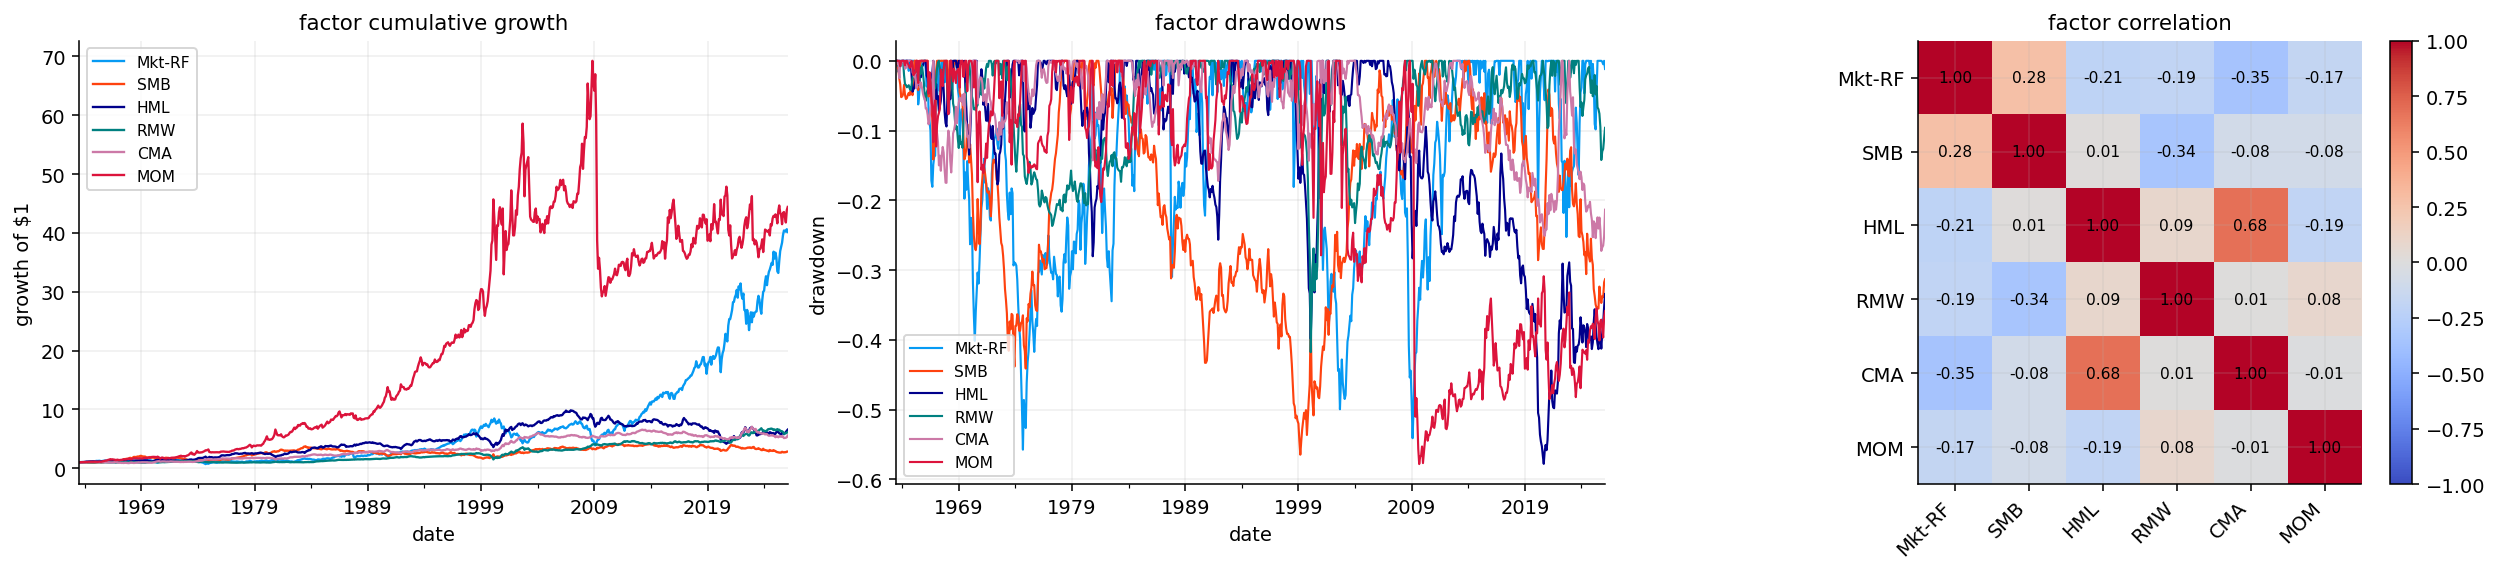

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.2))

factor_growth = (1.0 + factors).cumprod()
factor_growth.plot(ax=axes[0], lw=1.2)
axes[0].set_title("factor cumulative growth")
axes[0].set_ylabel("growth of $1")

factor_drawdown = factor_growth.apply(calc_drawdown)
factor_drawdown.plot(ax=axes[1], lw=1.1)
axes[1].set_title("factor drawdowns")
axes[1].set_ylabel("drawdown")

corr = factors.corr()
im = axes[2].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[2].set_title("factor correlation")
axes[2].set_xticks(range(len(corr.columns)))
axes[2].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[2].set_yticks(range(len(corr.index)))
axes[2].set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        axes[2].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

In [11]:
def full_sample_factor_regression(y, x):
    y = pd.DataFrame(y).astype(float)
    x = pd.DataFrame(x).astype(float)
    idx = y.index.intersection(x.index)
    y = y.loc[idx]
    x = x.loc[idx]
    rows = []
    beta_rows = {}
    for asset in y.columns:
        data = pd.concat([y[asset], x], axis=1).dropna()
        if len(data) <= x.shape[1] + 2:
            continue
        yy = data.iloc[:, 0].to_numpy(float)
        X = np.column_stack([np.ones(len(data)), data[x.columns].to_numpy(float)])
        coef = np.linalg.lstsq(X, yy, rcond=None)[0]
        fitted = X @ coef
        resid = yy - fitted
        sse = float(np.sum(resid ** 2))
        sst = float(np.sum((yy - yy.mean()) ** 2))
        rows.append({"asset": asset, "alpha": coef[0], "r2": 1.0 - sse / sst if sst > 0 else np.nan})
        beta_rows[asset] = pd.Series(coef[1:], index=x.columns)
    beta_out = pd.DataFrame(beta_rows).T
    stats_out = pd.DataFrame(rows).set_index("asset")
    return beta_out, stats_out

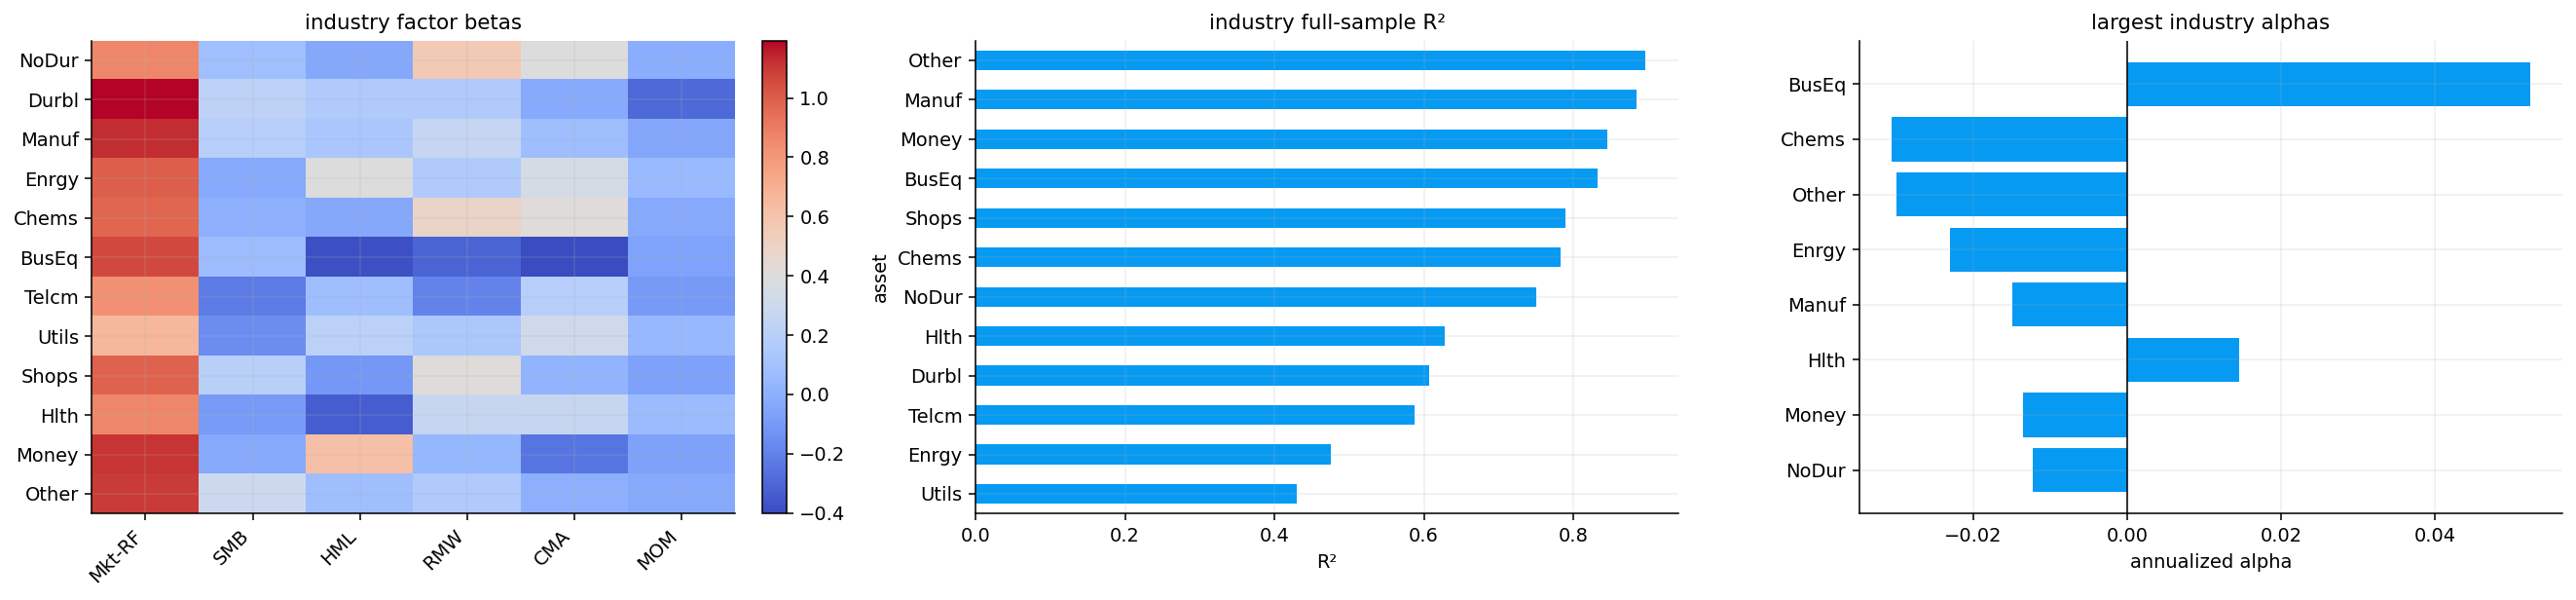

,alpha,r2,alpha_ann
asset,,,
Chems,-0.0026,0.7831,-0.0307
Other,-0.0025,0.8962,-0.0300
Enrgy,-0.0019,0.4750,-0.0230
Manuf,-0.0012,0.8844,-0.0150
Money,-0.0011,0.8457,-0.0136
NoDur,-0.0010,0.7502,-0.0123
Utils,-0.0008,0.4302,-0.0092
Durbl,0.0003,0.6071,0.0032
Telcm,0.0004,0.5874,0.0051


In [12]:
industry_beta, industry_stats = full_sample_factor_regression(
    industry_excess,
    factors.loc[industry_excess.index, factor_cols],
)

fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

im = axes[0].imshow(industry_beta, cmap="coolwarm", aspect="auto")
axes[0].set_title("industry factor betas")
axes[0].set_xticks(range(len(industry_beta.columns)))
axes[0].set_xticklabels(industry_beta.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(industry_beta.index)))
axes[0].set_yticklabels(industry_beta.index)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

industry_stats["r2"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("industry full-sample R²")
axes[1].set_xlabel("R²")

alpha_table = industry_stats.assign(alpha_ann=industry_stats["alpha"] * 12.0)
alpha_show = alpha_table.reindex(alpha_table["alpha_ann"].abs().sort_values(ascending=False).index).head(8)
axes[2].barh(alpha_show.index[::-1], alpha_show["alpha_ann"].iloc[::-1])
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set_title("largest industry alphas")
axes[2].set_xlabel("annualized alpha")

fig.tight_layout()
plt.show()

display(alpha_table.sort_values("alpha_ann").round(4))

In [13]:
factor_etfs = ["MTUM", "VLUE", "QUAL", "USMV", "RSP", "IWF", "IWD", "IWM"]
proxy_prices = load_yfinance_panel(
    etf_path,
    fields=("close",),
    tickers=factor_etfs + [cash_ticker, benchmark_ticker],
    start="1999-01-01",
)["close"].ffill(limit=3)
proxy_available = [t for t in factor_etfs if t in proxy_prices.columns and proxy_prices[t].notna().any()]
proxy_monthly_returns = proxy_prices.resample("ME").last().pct_change().dropna(how="all")
proxy_returns = proxy_monthly_returns[proxy_available]
proxy_dates = proxy_returns.index.intersection(factors.dropna(subset=factor_cols).index).intersection(rf.index)
proxy_excess = proxy_returns.loc[proxy_dates].subtract(rf.loc[proxy_dates], axis=0)
proxy_beta, proxy_stats = full_sample_factor_regression(proxy_excess, factors.loc[proxy_dates, factor_cols])

display(pd.DataFrame({"available factor ETF proxies": proxy_available}))

,available factor ETF proxies
0,MTUM
1,VLUE
2,QUAL
3,USMV
4,RSP
5,IWF
6,IWD
7,IWM


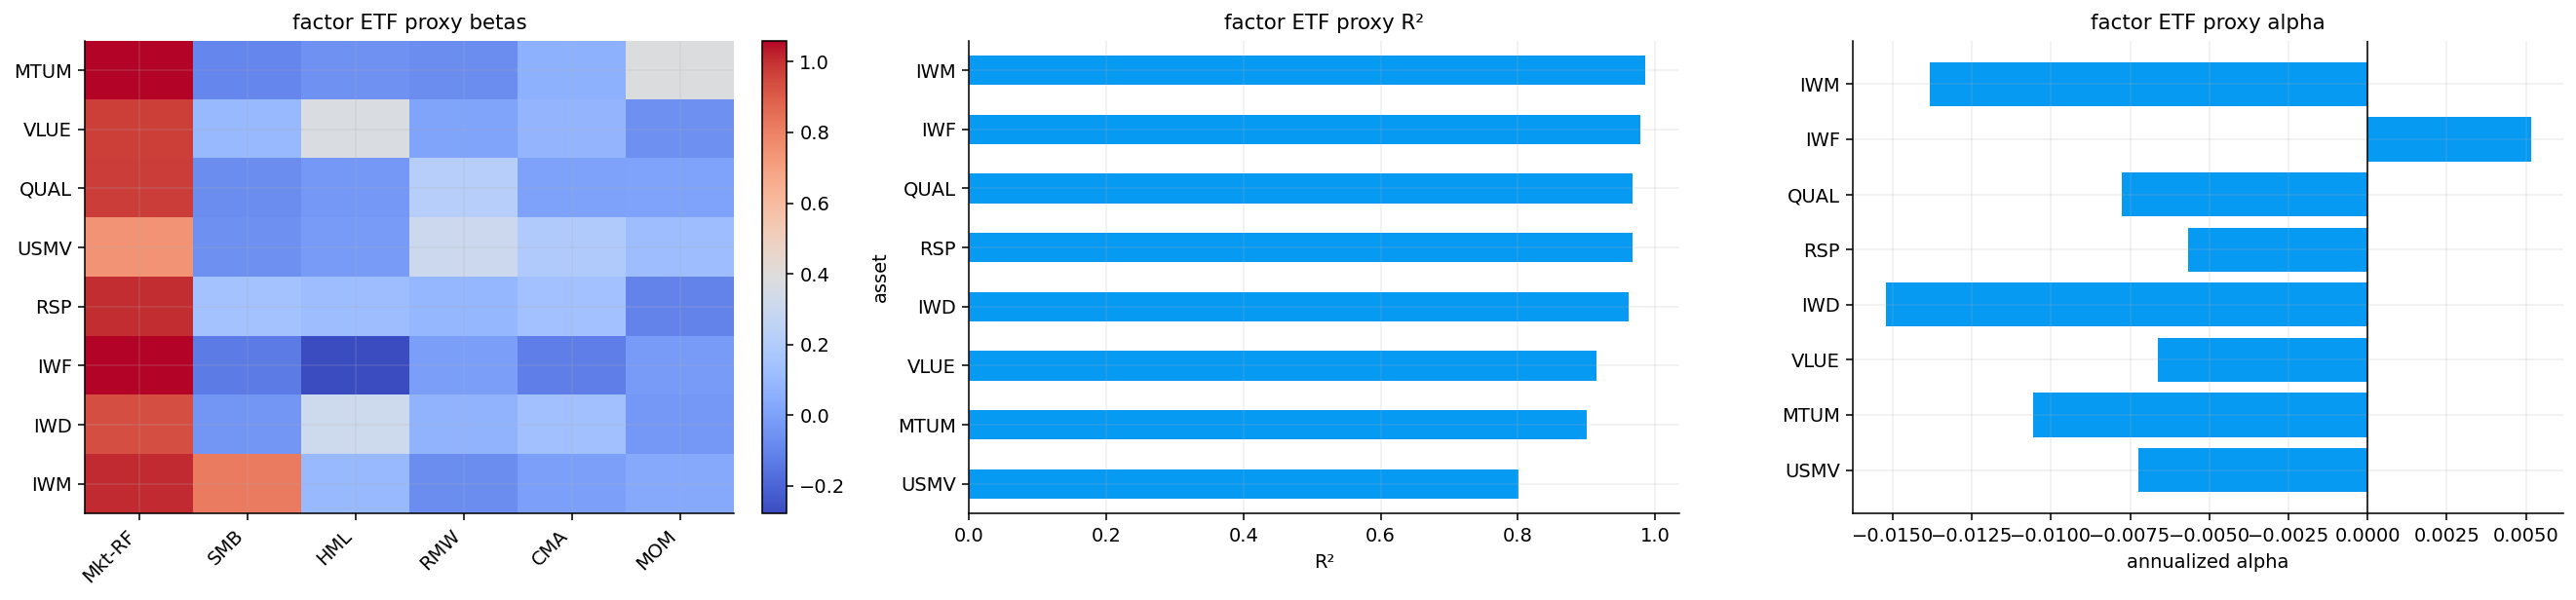

,alpha_ann,r2
asset,,
IWM,-0.0138,0.9861
IWF,0.0052,0.9780
QUAL,-0.0078,0.9667
RSP,-0.0057,0.9666
IWD,-0.0152,0.9617
VLUE,-0.0066,0.9146
MTUM,-0.0106,0.9004
USMV,-0.0072,0.8003


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

im = axes[0].imshow(proxy_beta, cmap="coolwarm", aspect="auto")
axes[0].set_title("factor ETF proxy betas")
axes[0].set_xticks(range(len(proxy_beta.columns)))
axes[0].set_xticklabels(proxy_beta.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(proxy_beta.index)))
axes[0].set_yticklabels(proxy_beta.index)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

proxy_stats["r2"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("factor ETF proxy R²")
axes[1].set_xlabel("R²")

proxy_table = proxy_stats.assign(alpha_ann=proxy_stats["alpha"] * 12.0).sort_values("r2", ascending=False)
axes[2].barh(proxy_table.index[::-1], proxy_table["alpha_ann"].iloc[::-1])
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set_title("factor ETF proxy alpha")
axes[2].set_xlabel("annualized alpha")

fig.tight_layout()
plt.show()

display(proxy_table[["alpha_ann", "r2"]].round(4))

In [15]:
valid_factor_dates = factors.dropna(subset=factor_cols).index
common_dates = sector_returns.index
common_dates = common_dates.intersection(cash_returns.index)
common_dates = common_dates.intersection(benchmark_returns.index)
common_dates = common_dates.intersection(valid_factor_dates)
common_dates = common_dates.intersection(rf.index)

sector_returns = sector_returns.loc[common_dates]
cash_returns = cash_returns.loc[common_dates]
benchmark_returns = benchmark_returns.loc[common_dates]
factors = factors.loc[common_dates, factor_cols]
rf = rf.loc[common_dates]
sector_excess = sector_returns.subtract(rf, axis=0)

alignment = pd.DataFrame(
    {
        "first date": [sector_returns.index.min(), cash_returns.index.min(), benchmark_returns.index.min(), factors.index.min(), rf.index.min()],
        "last date": [sector_returns.index.max(), cash_returns.index.max(), benchmark_returns.index.max(), factors.index.max(), rf.index.max()],
        "rows": [len(sector_returns), len(cash_returns), len(benchmark_returns), len(factors), len(rf)],
    },
    index=["sector returns", "cash returns", "benchmark returns", "factors", "rf"],
)
display(alignment)

,first date,last date,rows
sector returns,1999-02-28,2026-02-28,325
cash returns,1999-02-28,2026-02-28,325
benchmark returns,1999-02-28,2026-02-28,325
factors,1999-02-28,2026-02-28,325
rf,1999-02-28,2026-02-28,325


In [16]:
def rolling_factor_fit(y, x, window=60):
    y = pd.DataFrame(y).astype(float)
    x = pd.DataFrame(x).astype(float)
    idx = y.index.intersection(x.index)
    y = y.loc[idx]
    x = x.loc[idx]
    assets = list(y.columns)
    factor_names = list(x.columns)
    beta_cols = pd.MultiIndex.from_product([assets, factor_names], names=["asset", "factor"])
    alpha = pd.DataFrame(np.nan, index=idx, columns=assets)
    beta = pd.DataFrame(np.nan, index=idx, columns=beta_cols)
    r2 = pd.DataFrame(np.nan, index=idx, columns=assets)
    eps = pd.DataFrame(np.nan, index=idx, columns=assets)
    for i in range(window - 1, len(idx)):
        x_win = x.iloc[i - window + 1:i + 1]
        X_full = np.column_stack([np.ones(len(x_win)), x_win.to_numpy(float)])
        for asset in assets:
            y_win = y[asset].iloc[i - window + 1:i + 1]
            mask = np.isfinite(y_win.to_numpy(float)) & np.isfinite(X_full).all(axis=1)
            if mask.sum() < len(factor_names) + 3:
                continue
            X = X_full[mask]
            yy = y_win.to_numpy(float)[mask]
            coef = np.linalg.lstsq(X, yy, rcond=None)[0]
            fitted = X @ coef
            resid = yy - fitted
            sse = float(np.sum(resid ** 2))
            sst = float(np.sum((yy - yy.mean()) ** 2))
            date = idx[i]
            alpha.loc[date, asset] = coef[0]
            beta.loc[date, pd.IndexSlice[asset, :]] = coef[1:]
            r2.loc[date, asset] = 1.0 - sse / sst if sst > 0 else np.nan
            row_x = X_full[-1]
            if np.isfinite(row_x).all() and np.isfinite(y[asset].iloc[i]):
                eps.loc[date, asset] = float(y[asset].iloc[i] - row_x @ coef)
    return alpha, beta, r2, eps

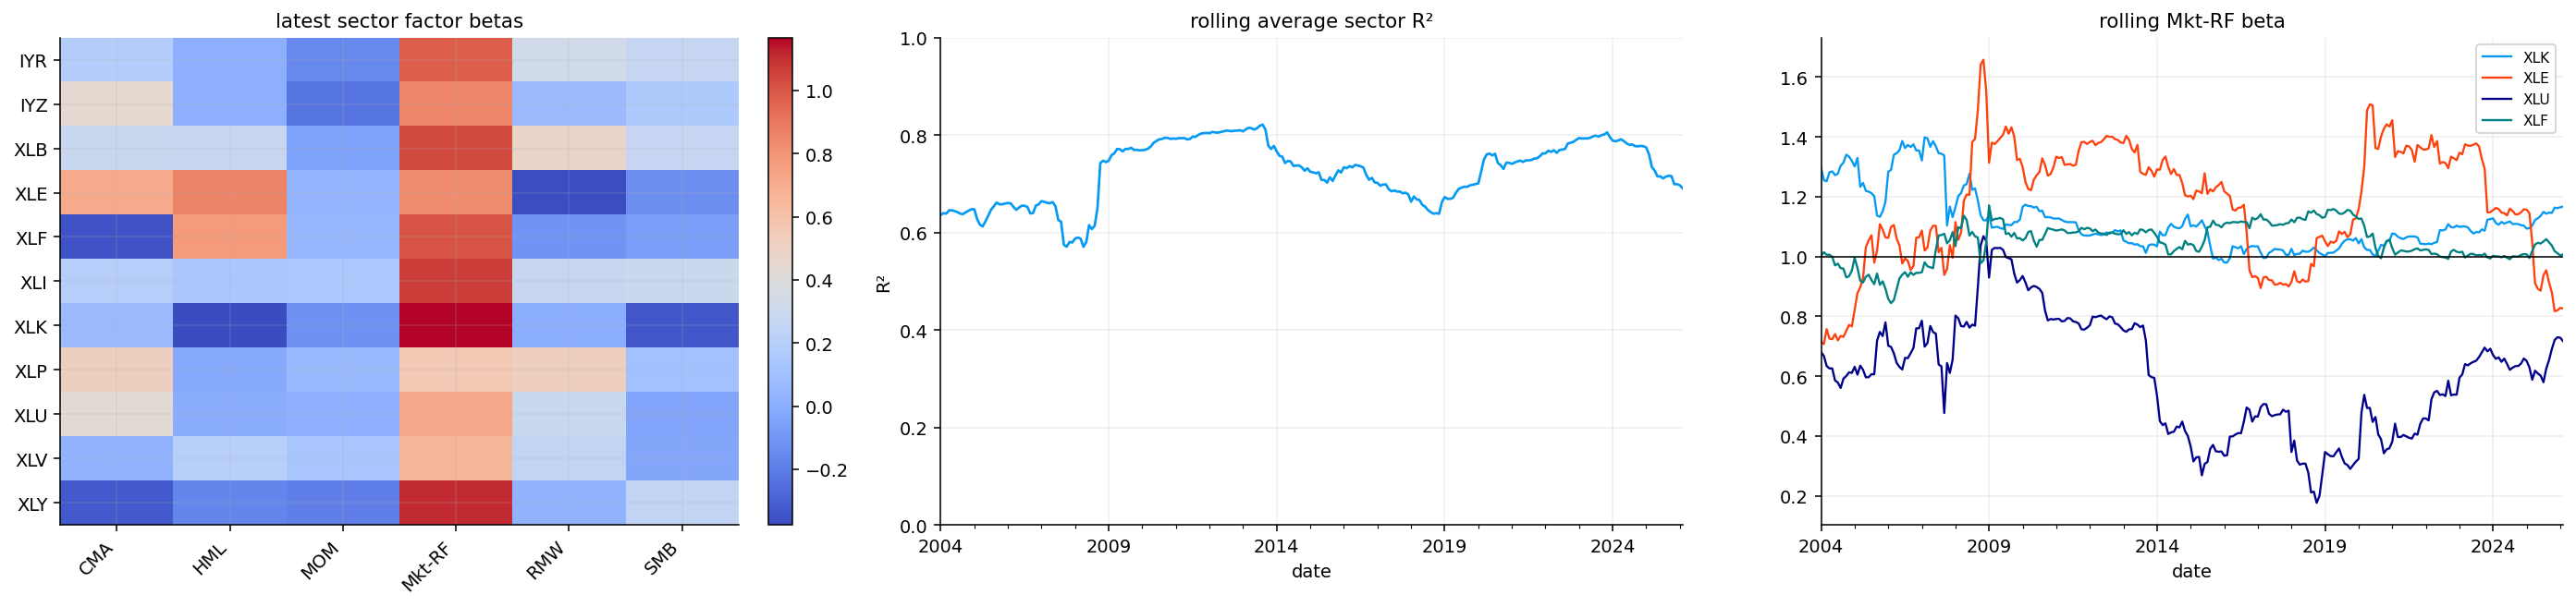

In [17]:
alpha, beta, r2, eps = rolling_factor_fit(sector_excess, factors, window=60)

latest_beta = beta.dropna(how="all").iloc[-1].unstack("factor")
fig, axes = plt.subplots(1, 3, figsize=(20, 4.8))

im = axes[0].imshow(latest_beta, cmap="coolwarm", aspect="auto")
axes[0].set_title("latest sector factor betas")
axes[0].set_xticks(range(len(latest_beta.columns)))
axes[0].set_xticklabels(latest_beta.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(latest_beta.index)))
axes[0].set_yticklabels(latest_beta.index)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

r2.mean(axis=1).dropna().plot(ax=axes[1], lw=1.4)
axes[1].set_title("rolling average sector R²")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, 1)

main_factor = "Mkt-RF" if "Mkt-RF" in factor_cols else factor_cols[0]
for ticker in [t for t in ["XLK", "XLE", "XLU", "XLF"] if t in sector_tickers]:
    beta[(ticker, main_factor)].dropna().plot(ax=axes[2], lw=1.2, label=ticker)
axes[2].set_title(f"rolling {main_factor} beta")
axes[2].axhline(1.0, color="black", lw=0.8)
axes[2].legend()

fig.tight_layout()
plt.show()

In [18]:
def factor_state(factors, short_window=6, long_window=12, vol_window=36, skip=1, clip=2.0):
    f = pd.DataFrame(factors).astype(float)
    short = (1.0 + f).rolling(short_window).apply(np.prod, raw=True) - 1.0
    long_len = max(long_window - skip, 1)
    long = (1.0 + f.shift(skip)).rolling(long_len).apply(np.prod, raw=True) - 1.0
    vol = f.rolling(vol_window).std().replace(0.0, np.nan) * np.sqrt(12.0)
    raw = (0.45 * short + 0.55 * long) / vol
    mean = raw.rolling(vol_window).mean()
    sd = raw.rolling(vol_window).std().replace(0.0, np.nan)
    return ((raw - mean) / sd).clip(-clip, clip)


def factor_proxy_spreads(returns, benchmark_ticker="SPY", cash_ticker="SHY"):
    r = pd.DataFrame(returns).astype(float)
    out = {}
    if benchmark_ticker in r.columns and cash_ticker in r.columns:
        out["Mkt-RF"] = r[benchmark_ticker] - r[cash_ticker]
    elif benchmark_ticker in r.columns:
        out["Mkt-RF"] = r[benchmark_ticker]
    if "IWM" in r.columns and benchmark_ticker in r.columns:
        out["SMB"] = r["IWM"] - r[benchmark_ticker]
    elif "RSP" in r.columns and benchmark_ticker in r.columns:
        out["SMB"] = r["RSP"] - r[benchmark_ticker]
    if "IWD" in r.columns and "IWF" in r.columns:
        out["HML"] = r["IWD"] - r["IWF"]
    elif "VLUE" in r.columns and benchmark_ticker in r.columns:
        out["HML"] = r["VLUE"] - r[benchmark_ticker]
    if "QUAL" in r.columns and benchmark_ticker in r.columns:
        out["RMW"] = r["QUAL"] - r[benchmark_ticker]
    if "USMV" in r.columns and benchmark_ticker in r.columns:
        out["CMA"] = r["USMV"] - r[benchmark_ticker]
    if "MTUM" in r.columns and benchmark_ticker in r.columns:
        out["MOM"] = r["MTUM"] - r[benchmark_ticker]
    return pd.DataFrame(out).sort_index()


def blend_factor_states(academic_state, tradable_state, academic_weight=0.70, disagreement_scale=0.50):
    a = pd.DataFrame(academic_state).astype(float)
    t = pd.DataFrame(tradable_state).astype(float)
    idx = a.index.intersection(t.index)
    out = a.copy()
    cols = a.columns.intersection(t.columns)
    if len(idx) == 0 or len(cols) == 0:
        return out
    blended = academic_weight * a.loc[idx, cols] + (1.0 - academic_weight) * t.loc[idx, cols]
    agree = np.sign(a.loc[idx, cols]) * np.sign(t.loc[idx, cols]) >= 0
    out.loc[idx, cols] = blended.where(agree, blended * disagreement_scale)
    return out

,academic,tradable,blended
Mkt-RF,0.4290,0.2760,0.3830
SMB,2.0000,2.0000,2.0000
HML,1.5640,2.0000,1.6950
RMW,-1.1640,-0.4050,-0.9360
CMA,1.2090,-0.5830,0.3360
MOM,0.7860,-0.2710,0.2340


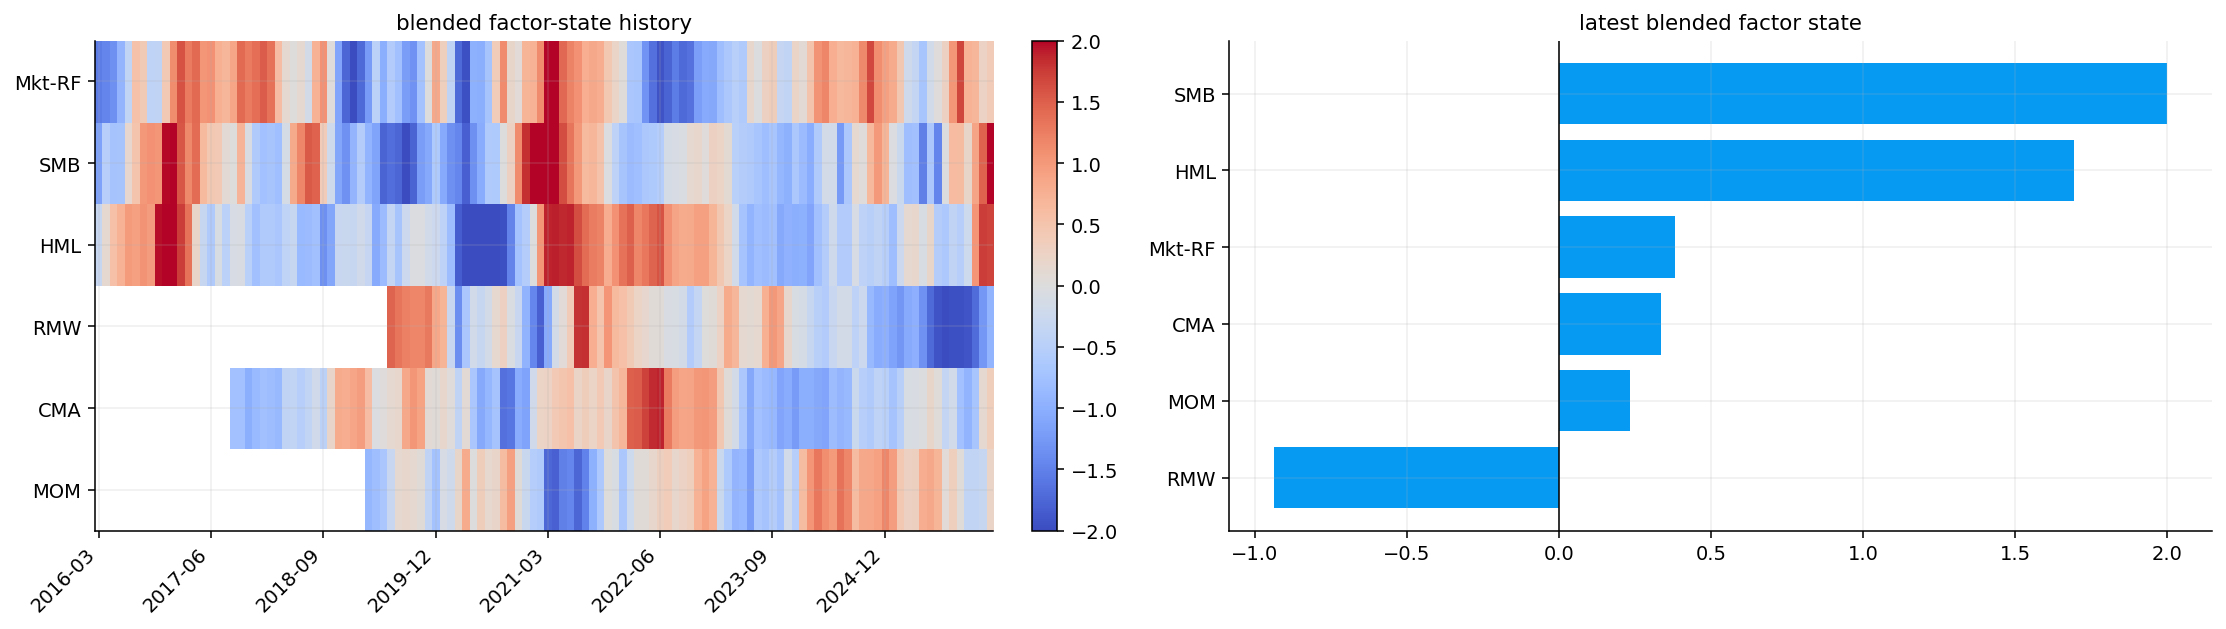

In [19]:
z_academic = factor_state(factors, short_window=6, long_window=12, vol_window=36, skip=1, clip=2.0)
tradable_spreads = factor_proxy_spreads(proxy_monthly_returns, benchmark_ticker=benchmark_ticker, cash_ticker=cash_ticker)
tradable_spreads = tradable_spreads.reindex(common_dates)
z_tradable = factor_state(tradable_spreads, short_window=6, long_window=12, vol_window=36, skip=1, clip=2.0)
z_factor = blend_factor_states(z_academic, z_tradable, academic_weight=0.70, disagreement_scale=0.50)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
z_plot = z_factor.dropna(how="all").tail(120).T
im = axes[0].imshow(z_plot, cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
axes[0].set_title("blended factor-state history")
axes[0].set_yticks(range(len(z_plot.index)))
axes[0].set_yticklabels(z_plot.index)
step = max(1, len(z_plot.columns) // 8)
locs = list(range(0, len(z_plot.columns), step))
axes[0].set_xticks(locs)
axes[0].set_xticklabels([z_plot.columns[i].strftime("%Y-%m") for i in locs], rotation=45, ha="right")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

latest_factor_state_table = pd.concat(
    {
        "academic": z_academic.dropna(how="all").iloc[-1],
        "tradable": z_tradable.reindex(z_academic.index).dropna(how="all").iloc[-1],
        "blended": z_factor.dropna(how="all").iloc[-1],
    },
    axis=1,
)
display(latest_factor_state_table.round(3))

latest_z = z_factor.dropna(how="all").iloc[-1].sort_values()
axes[1].barh(latest_z.index, latest_z.values)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("latest blended factor state")

fig.tight_layout()
plt.show()

In [20]:
def cross_section_z(values):
    v = pd.DataFrame(values).astype(float)
    mean = v.mean(axis=1)
    sd = v.std(axis=1, ddof=0).replace(0.0, np.nan)
    return v.subtract(mean, axis=0).divide(sd, axis=0)


def factor_scores(beta, z_factor):
    z = pd.DataFrame(z_factor).astype(float)
    dates = beta.index.intersection(z.index)
    assets = beta.columns.get_level_values("asset").unique()
    out = pd.DataFrame(np.nan, index=dates, columns=assets)
    for date in dates:
        b = beta.loc[date].unstack("factor")
        cols = b.columns.intersection(z.columns)
        if len(cols):
            out.loc[date, b.index] = b[cols].dot(z.loc[date, cols])
    return out

,s_factor
asset,
XLE,1.8930
XLF,1.1950
XLI,0.5790
XLB,0.4790
IYZ,0.0450
IYR,-0.0070
XLY,-0.2460
XLV,-0.4210
XLP,-0.7240


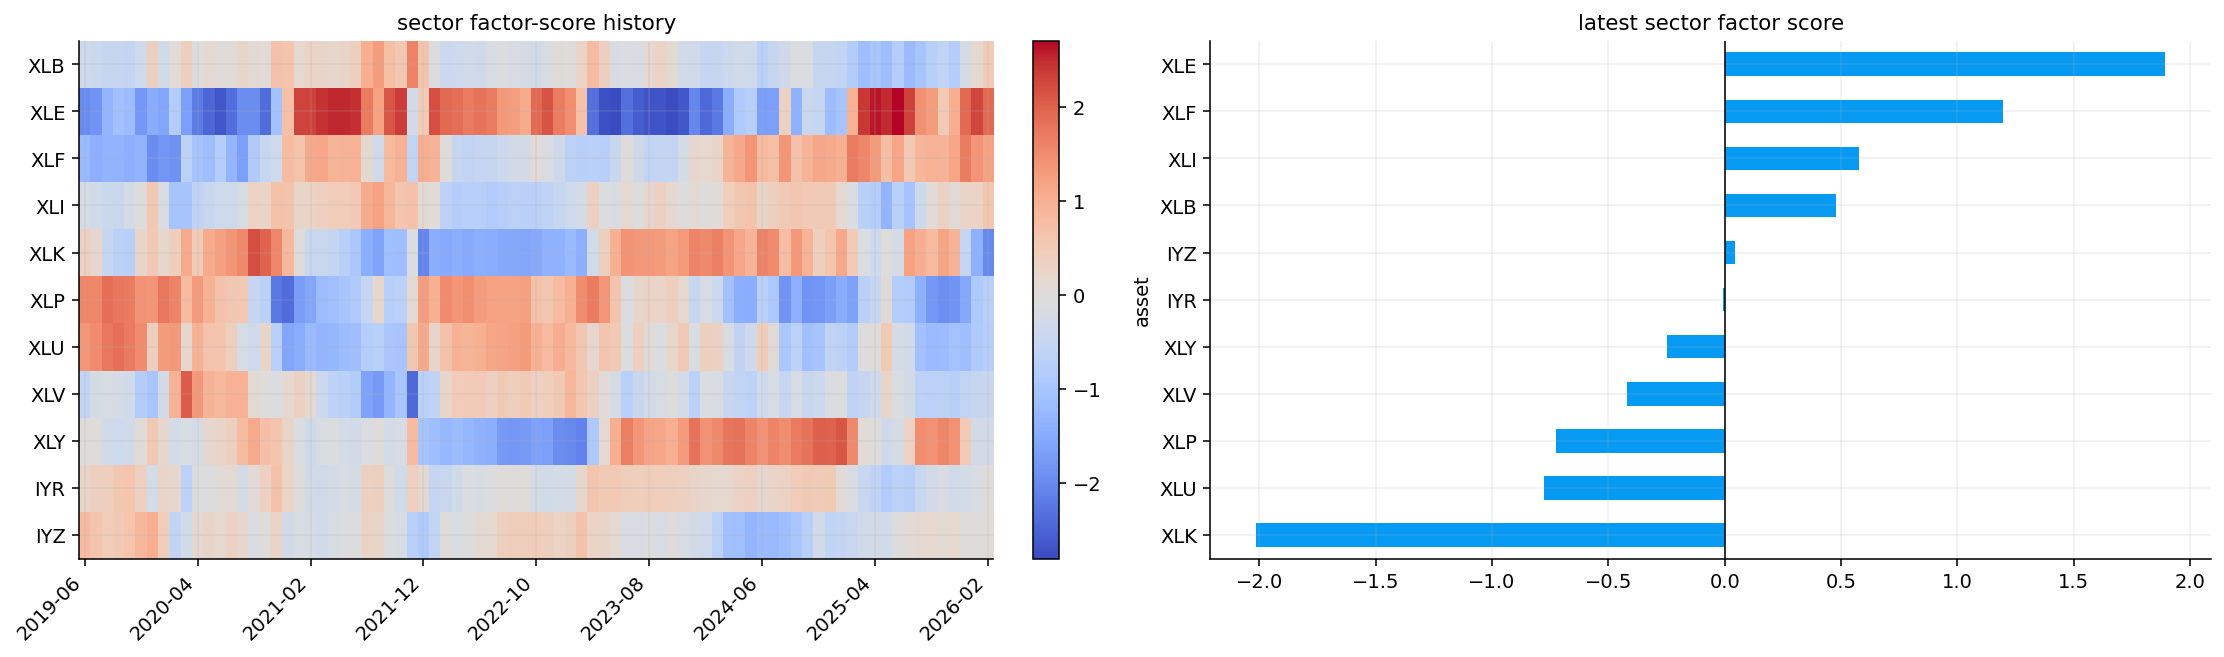

In [21]:
s_factor = factor_scores(beta, z_factor)
s_factor = cross_section_z(s_factor)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
score_plot = s_factor.dropna(how="all").tail(84).T
im = axes[0].imshow(score_plot, cmap="coolwarm", aspect="auto")
axes[0].set_title("sector factor-score history")
axes[0].set_yticks(range(len(score_plot.index)))
axes[0].set_yticklabels(score_plot.index)
step = max(1, len(score_plot.columns) // 8)
locs = list(range(0, len(score_plot.columns), step))
axes[0].set_xticks(locs)
axes[0].set_xticklabels([score_plot.columns[i].strftime("%Y-%m") for i in locs], rotation=45, ha="right")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

latest_factor_score = s_factor.dropna(how="all").iloc[-1].sort_values(ascending=False)
display(latest_factor_score.to_frame("s_factor").round(3))
latest_factor_score.sort_values().plot(kind="barh", ax=axes[1])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("latest sector factor score")

fig.tight_layout()
plt.show()

In [22]:
def residual_strength(eps, window=6):
    return pd.DataFrame(eps).astype(float).rolling(window).sum()


def trend_strength(returns, window=12, skip=1):
    length = max(window - skip, 1)
    return (1.0 + returns.shift(skip)).rolling(length).apply(np.prod, raw=True) - 1.0


def risk_penalty(returns, vol_window=36, drawdown_window=12):
    vol = returns.rolling(vol_window).std() * np.sqrt(12.0)
    nav = (1.0 + returns.fillna(0.0)).cumprod()
    peak = nav.rolling(drawdown_window, min_periods=drawdown_window).max()
    drawdown = (nav / peak - 1.0).clip(upper=0.0)
    return vol + drawdown.abs()

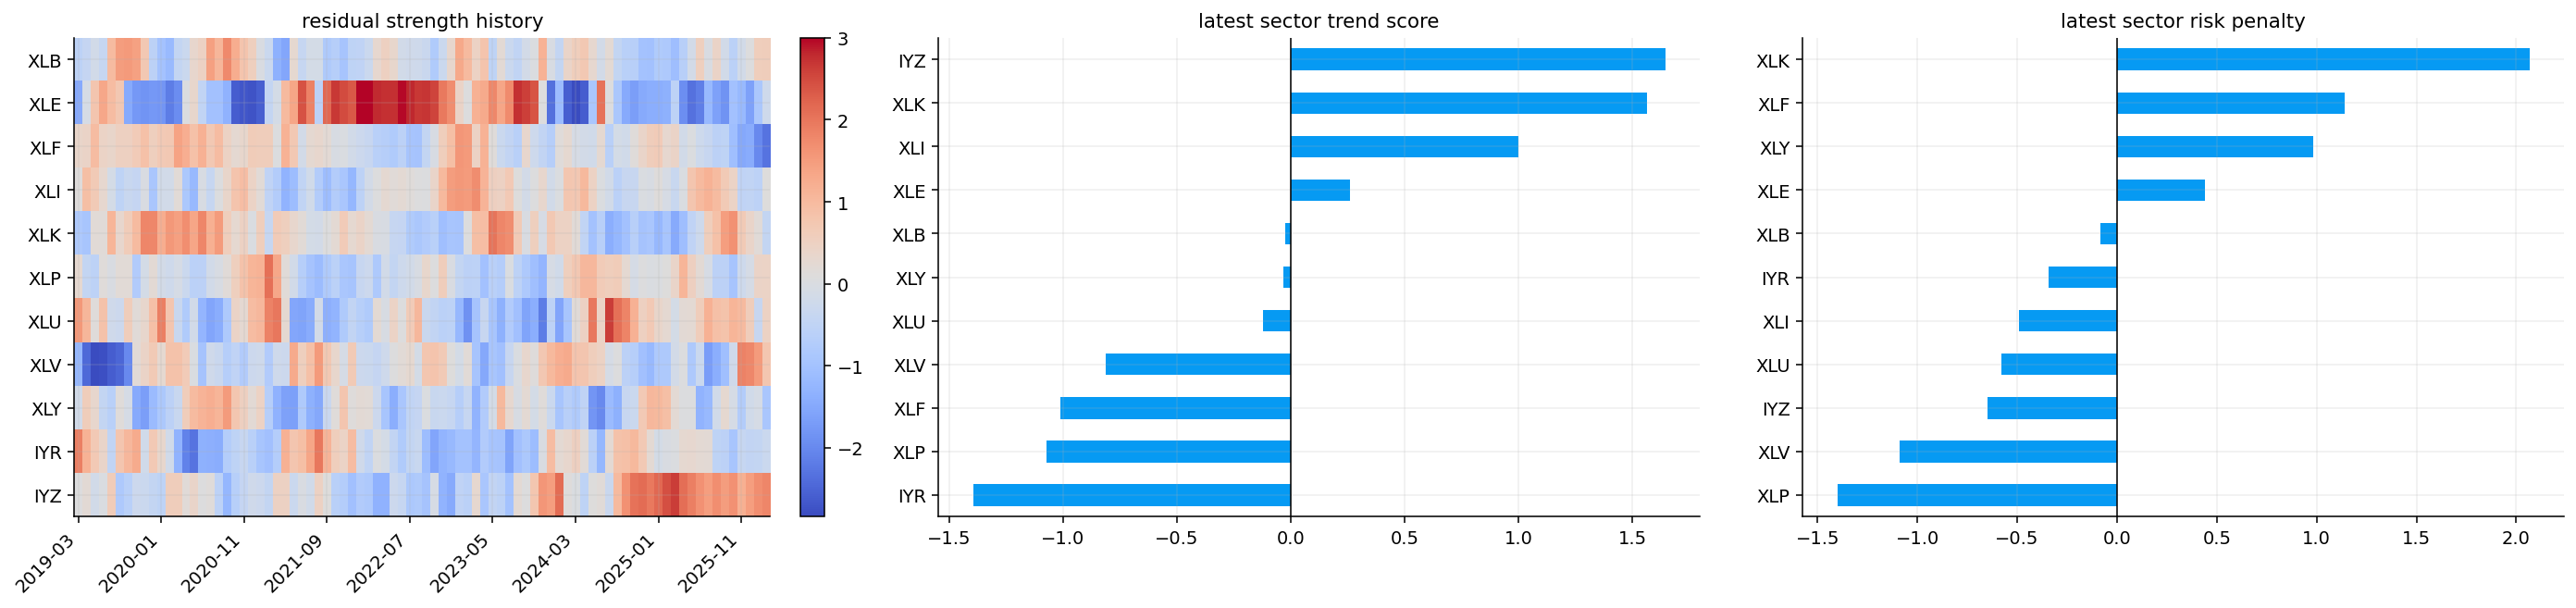

In [23]:
raw_risk = risk_penalty(sector_returns, vol_window=36, drawdown_window=12)
s_resid = cross_section_z(residual_strength(eps, window=6))
s_trend = cross_section_z(trend_strength(sector_returns, window=12, skip=1))
s_risk = cross_section_z(raw_risk)

fig, axes = plt.subplots(1, 3, figsize=(20, 4.8))
resid_plot = s_resid.dropna(how="all").tail(84).T
im = axes[0].imshow(resid_plot, cmap="coolwarm", aspect="auto")
axes[0].set_title("residual strength history")
axes[0].set_yticks(range(len(resid_plot.index)))
axes[0].set_yticklabels(resid_plot.index)
step = max(1, len(resid_plot.columns) // 8)
locs = list(range(0, len(resid_plot.columns), step))
axes[0].set_xticks(locs)
axes[0].set_xticklabels([resid_plot.columns[i].strftime("%Y-%m") for i in locs], rotation=45, ha="right")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

s_trend.dropna(how="all").iloc[-1].sort_values().plot(kind="barh", ax=axes[1])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("latest sector trend score")

s_risk.dropna(how="all").iloc[-1].sort_values().plot(kind="barh", ax=axes[2])
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set_title("latest sector risk penalty")

fig.tight_layout()
plt.show()

,s_dynamic
XLE,1.0790
IYZ,0.7620
XLI,0.5340
XLB,0.4210
XLF,-0.0600
XLV,-0.1980
IYR,-0.3250
XLU,-0.3560
XLY,-0.3670
XLP,-0.4970


,factor,residual,trend,risk
date,,,,
2025-03-31,0.5770,0.3000,0.1230,0.2000
2025-04-30,0.5320,0.3000,0.1680,0.0000
2025-05-31,0.5570,0.3000,0.1430,0.2000
2025-06-30,0.5130,0.3000,0.1870,0.0000
2025-07-31,0.4950,0.3000,0.2050,0.2000
2025-08-31,0.5410,0.3000,0.1590,0.2000
2025-09-30,0.5130,0.3000,0.1870,0.0000
2025-10-31,0.5070,0.3000,0.1930,0.0000
2025-11-30,0.5190,0.3000,0.1810,0.2000


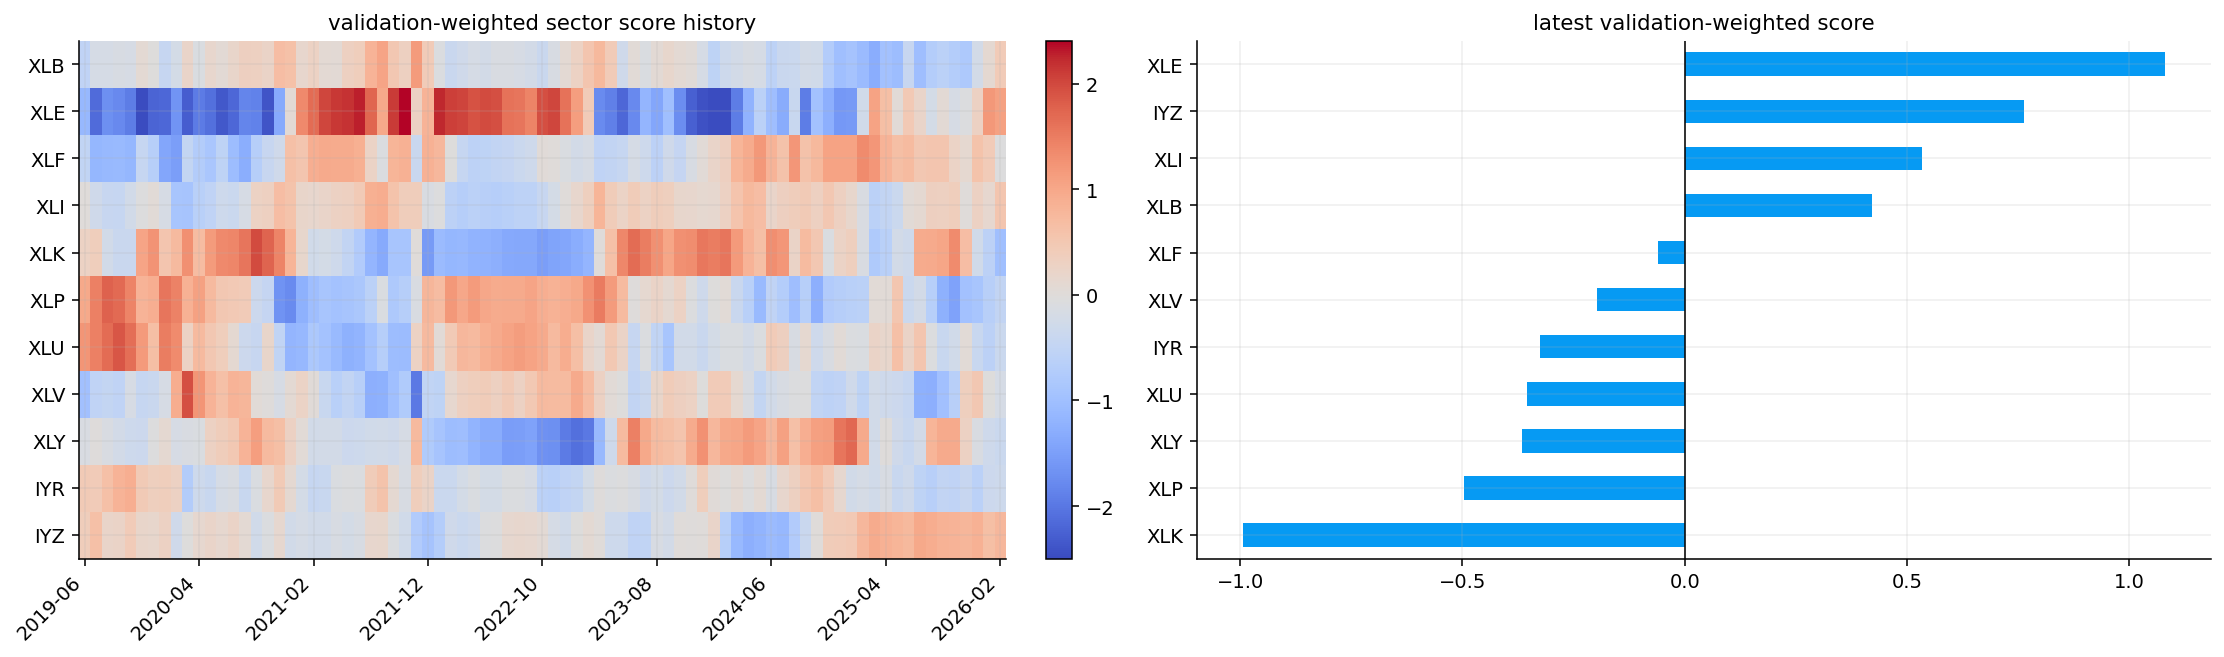

In [24]:
def rank_ic_series(score, future_returns):
    vals = []
    for date in score.index.intersection(future_returns.index):
        s = score.loc[date]
        r = future_returns.loc[date].reindex(s.index)
        mask = s.notna() & r.notna()
        vals.append(s[mask].rank().corr(r[mask].rank()) if mask.sum() >= 3 else np.nan)
    return pd.Series(vals, index=score.index.intersection(future_returns.index), name="rank_ic")


def top_active_series(score, future_returns, top_n=4):
    vals = []
    for date in score.index.intersection(future_returns.index):
        s = score.loc[date].dropna().sort_values(ascending=False)
        r = future_returns.loc[date].reindex(s.index)
        if len(s) < top_n:
            vals.append((date, np.nan))
            continue
        top = r.reindex(s.head(top_n).index).mean()
        avg = r.mean()
        vals.append((date, top - avg if np.isfinite(top) and np.isfinite(avg) else np.nan))
    return pd.Series(dict(vals)).sort_index()


def top_return_series(score, future_returns, top_n=4):
    vals = []
    for date in score.index.intersection(future_returns.index):
        s = score.loc[date].dropna().sort_values(ascending=False)
        r = future_returns.loc[date].reindex(s.index)
        if len(s) < top_n:
            vals.append((date, np.nan))
            continue
        vals.append((date, r.reindex(s.head(top_n).index).mean()))
    return pd.Series(dict(vals)).sort_index()


def max_drawdown_from_returns(returns):
    r = pd.Series(returns, dtype=float).dropna()
    if r.empty:
        return np.nan
    nav = (1.0 + r).cumprod()
    return (nav / nav.cummax() - 1.0).min()



def component_weights(raw_weights, base_weights=None, validation_strength=1.0, max_component_weights=None):
    vals = pd.Series(raw_weights, dtype=float).replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(lower=0.0)
    if vals.sum() <= 1e-12:
        vals.loc[:] = 1.0 / len(vals)
    else:
        vals = vals / vals.sum()
    if base_weights is not None:
        base = pd.Series(base_weights, dtype=float).reindex(vals.index).fillna(0.0).clip(lower=0.0)
        if base.sum() > 1e-12:
            base = base / base.sum()
            strength = np.clip(validation_strength, 0.0, 1.0)
            vals = (1.0 - strength) * base + strength * vals
            vals = vals / vals.sum()
    if max_component_weights is not None:
        caps = pd.Series(max_component_weights, dtype=float).reindex(vals.index).fillna(1.0).clip(lower=0.0, upper=1.0)
        for _ in range(len(vals) + 2):
            vals = vals.clip(upper=caps)
            deficit = 1.0 - vals.sum()
            if deficit <= 1e-12:
                break
            room = (caps - vals).clip(lower=0.0)
            if room.sum() <= 1e-12:
                break
            vals = vals + deficit * room / room.sum()
        if vals.sum() > 1e-12:
            vals = vals / vals.sum()
    return vals.to_dict()


def validation_weighted_score(scores, future_returns, risk=None, window=72, min_periods=36, top_n=4, risk_weight=0.20, base_weights=None, validation_strength=1.0, max_component_weights=None):
    frames = {name: pd.DataFrame(value).astype(float) for name, value in scores.items()}
    future = pd.DataFrame(future_returns).astype(float)
    idx = future.index
    cols = future.columns
    for frame in frames.values():
        idx = idx.intersection(frame.index)
        cols = cols.intersection(frame.columns)
    risk_frame = pd.DataFrame(risk).astype(float) if risk is not None else None
    if risk_frame is not None:
        idx = idx.intersection(risk_frame.index)
        cols = cols.intersection(risk_frame.columns)
    idx = pd.DatetimeIndex(idx).sort_values()
    out = pd.DataFrame(np.nan, index=idx, columns=cols)
    score_weights = pd.DataFrame(np.nan, index=idx, columns=list(frames.keys()) + ["risk"])
    ic = {name: rank_ic_series(frame.reindex(index=idx, columns=cols), future.reindex(index=idx, columns=cols)) for name, frame in frames.items()}
    active = {name: top_active_series(frame.reindex(index=idx, columns=cols), future.reindex(index=idx, columns=cols), top_n=top_n) for name, frame in frames.items()}
    for i, date in enumerate(idx):
        hist = idx[max(0, i - window):i]
        if len(hist) < min_periods:
            continue
        edges = {}
        for name in frames:
            ic_mean = ic[name].reindex(hist).mean()
            active_mean = active[name].reindex(hist).mean()
            edges[name] = max(0.0, ic_mean if np.isfinite(ic_mean) else 0.0) * max(0.0, active_mean if np.isfinite(active_mean) else 0.0)
        edge_sum = sum(edges.values())
        raw_weights = {name: edge / edge_sum for name, edge in edges.items()} if edge_sum > 1e-12 else {name: 1.0 / len(frames) for name in frames}
        weights_now = component_weights(
            raw_weights,
            base_weights=base_weights,
            validation_strength=validation_strength,
            max_component_weights=max_component_weights,
        )
        base_score = pd.Series(0.0, index=cols, dtype=float)
        hist_score = pd.DataFrame(0.0, index=hist, columns=cols)
        for name, frame in frames.items():
            base_score = base_score + weights_now[name] * frame.loc[date, cols]
            hist_score = hist_score + weights_now[name] * frame.loc[hist, cols]
        risk_use = 0.0
        if risk_frame is not None:
            candidate_hist = hist_score - risk_weight * risk_frame.loc[hist, cols]
            base_active = top_active_series(hist_score, future.reindex(index=hist, columns=cols), top_n=top_n).mean()
            candidate_active = top_active_series(candidate_hist, future.reindex(index=hist, columns=cols), top_n=top_n).mean()
            base_dd = max_drawdown_from_returns(top_return_series(hist_score, future.reindex(index=hist, columns=cols), top_n=top_n))
            candidate_dd = max_drawdown_from_returns(top_return_series(candidate_hist, future.reindex(index=hist, columns=cols), top_n=top_n))
            active_ok = np.isfinite(candidate_active) and np.isfinite(base_active) and candidate_active >= base_active
            drawdown_ok = np.isfinite(candidate_dd) and np.isfinite(base_dd) and candidate_dd >= base_dd
            if active_ok or drawdown_ok:
                risk_use = risk_weight
                base_score = base_score - risk_use * risk_frame.loc[date, cols]
        out.loc[date] = base_score
        for name, value in weights_now.items():
            score_weights.loc[date, name] = value
        score_weights.loc[date, "risk"] = risk_use
    return out, score_weights


next_returns = sector_returns.shift(-1)
s_total, validation_weights = validation_weighted_score(
    {"factor": s_factor, "residual": s_resid, "trend": s_trend},
    next_returns,
    risk=s_risk,
    window=72,
    min_periods=36,
    top_n=4,
    risk_weight=0.20,
    base_weights={"factor": 0.60, "residual": 0.25, "trend": 0.15},
    validation_strength=0.50,
    max_component_weights={"residual": 0.30, "trend": 0.25},
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
total_plot = s_total.dropna(how="all").tail(84).T
im = axes[0].imshow(total_plot, cmap="coolwarm", aspect="auto")
axes[0].set_title("validation-weighted sector score history")
axes[0].set_yticks(range(len(total_plot.index)))
axes[0].set_yticklabels(total_plot.index)
step = max(1, len(total_plot.columns) // 8)
locs = list(range(0, len(total_plot.columns), step))
axes[0].set_xticks(locs)
axes[0].set_xticklabels([total_plot.columns[i].strftime("%Y-%m") for i in locs], rotation=45, ha="right")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

latest_total_score = s_total.dropna(how="all").iloc[-1].sort_values(ascending=False)
display(latest_total_score.to_frame("s_dynamic").round(3))
display(validation_weights.dropna(how="all").tail(12).round(3))
latest_total_score.sort_values().plot(kind="barh", ax=axes[1])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("latest validation-weighted score")

fig.tight_layout()
plt.show()

In [25]:
def rank_ic_series(score, future_returns):
    vals = []
    for date in score.index.intersection(future_returns.index):
        s = score.loc[date]
        r = future_returns.loc[date].reindex(s.index)
        mask = s.notna() & r.notna()
        vals.append(s[mask].rank().corr(r[mask].rank()) if mask.sum() >= 3 else np.nan)
    return pd.Series(vals, index=score.index.intersection(future_returns.index), name="rank_ic")


def signal_validation(scores, future_returns, top_n=4, bottom_n=4):
    rows = []
    spreads = {}
    top_active = {}
    ic_series = {}
    avg = future_returns.mean(axis=1)
    for name, score in scores.items():
        ic = rank_ic_series(score, future_returns)
        ic_series[name] = ic
        spread_vals = []
        active_vals = []
        for date in score.index.intersection(future_returns.index):
            s = score.loc[date].dropna().sort_values(ascending=False)
            if len(s) < max(top_n, bottom_n):
                continue
            r = future_returns.loc[date].reindex(s.index)
            top = r.reindex(s.head(top_n).index).mean()
            bottom = r.reindex(s.tail(bottom_n).index).mean()
            if np.isfinite(top) and np.isfinite(bottom):
                spread_vals.append(top - bottom)
                active_vals.append(top - avg.loc[date])
        spread_s = pd.Series(spread_vals, dtype=float)
        active_s = pd.Series(active_vals, dtype=float)
        spreads[name] = spread_s
        top_active[name] = active_s
        rows.append(
            {
                "signal": name,
                "rank IC": ic.mean(),
                "top-minus-bottom": spread_s.mean(),
                "top-4 vs average": active_s.mean(),
                "hit rate": (spread_s > 0).mean(),
                "n": spread_s.count(),
            }
        )
    return pd.DataFrame(rows).set_index("signal"), pd.DataFrame(ic_series), spreads, top_active

In [26]:
signals = {
    "s_factor": s_factor,
    "s_resid": s_resid,
    "s_trend": s_trend,
    "s_total": s_total,
}
future_returns = sector_returns.shift(-1)
validation_table, ic_history, spread_map, active_map = signal_validation(signals, future_returns, top_n=4, bottom_n=4)

display(validation_table.round(4))

,rank IC,top-minus-bottom,top-4 vs average,hit rate,n
signal,,,,,
s_factor,0.0381,0.0051,0.0020,0.5250,80
s_resid,-0.0082,0.0008,0.0010,0.5231,260
s_trend,0.0181,0.0001,0.0004,0.5112,313
s_total,0.0610,0.0062,0.0040,0.5000,80


In [27]:
def signal_decay(scores, returns, horizons=(1, 3, 6), top_n=4):
    rows = []
    for h in horizons:
        future = (1.0 + returns).rolling(h).apply(np.prod, raw=True).shift(-h) - 1.0
        avg = future.mean(axis=1)
        for name, score in scores.items():
            vals = []
            active = []
            for date in score.index.intersection(future.index):
                s = score.loc[date].dropna().sort_values(ascending=False)
                if len(s) < top_n:
                    continue
                ret = future.loc[date, s.head(top_n).index].mean()
                base = avg.loc[date]
                if np.isfinite(ret) and np.isfinite(base):
                    vals.append(ret)
                    active.append(ret - base)
            active_s = pd.Series(active, dtype=float)
            rows.append(
                {
                    "signal": name,
                    "horizon": h,
                    "top return": np.mean(vals) if vals else np.nan,
                    "active return": active_s.mean(),
                    "hit rate": (active_s > 0).mean(),
                    "n": active_s.count(),
                }
            )
    return pd.DataFrame(rows).set_index(["signal", "horizon"])


decay_table = signal_decay(signals, sector_returns, horizons=(1, 3, 6), top_n=4)
display(decay_table.round(4))

,,top return,active return,hit rate,n
signal,horizon,,,,
s_factor,1,0.0130,0.0020,0.5125,80
s_resid,1,0.0098,0.0010,0.5154,260
s_trend,1,0.0081,0.0004,0.5112,313
s_total,1,0.0149,0.0040,0.5500,80
s_factor,3,0.0359,0.0047,0.5256,78
s_resid,3,0.0271,0.0008,0.4922,258
s_trend,3,0.0233,0.0006,0.5305,311
s_total,3,0.0383,0.0071,0.5897,78
s_factor,6,0.0714,0.0099,0.6000,75


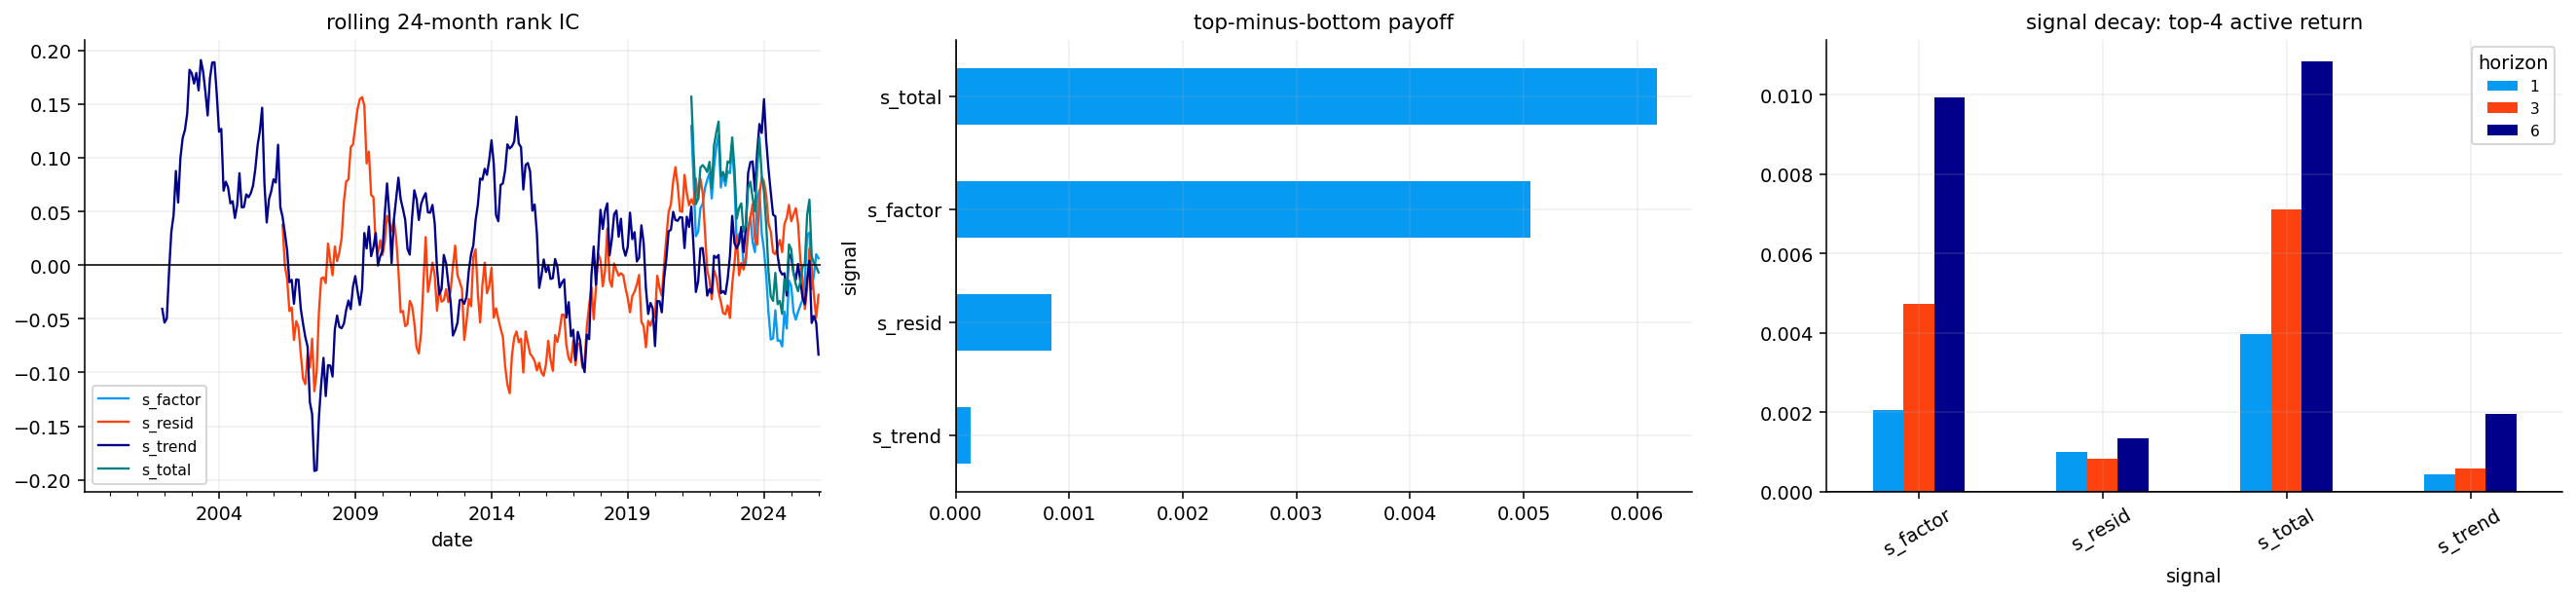

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(19, 4.5))

ic_history.rolling(24).mean().plot(ax=axes[0], lw=1.2)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("rolling 24-month rank IC")

validation_table["top-minus-bottom"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("top-minus-bottom payoff")

active_decay = decay_table["active return"].unstack("horizon")
active_decay.plot(kind="bar", ax=axes[2])
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("signal decay: top-4 active return")
axes[2].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

In [29]:
def soft_active_weights(
    scores,
    returns,
    cash_returns=None,
    risk_score=None,
    active_budget=0.35,
    min_weight=0.02,
    max_weight=0.25,
    turnover_limit=0.25,
    cash_ticker="SHY",
    cash_weight_max=0.25,
    risk_window=36,
    risk_quantile=0.70,
):
    s = pd.DataFrame(scores).astype(float)
    r = pd.DataFrame(returns).astype(float)
    assets = list(s.columns.intersection(r.columns))
    idx = s.index.intersection(r.index)
    cash = pd.Series(cash_returns, dtype=float) if cash_returns is not None else None
    if cash is not None:
        idx = idx.intersection(cash.index)
    out_cols = assets + ([cash_ticker] if cash is not None else [])
    out = pd.DataFrame(0.0, index=idx, columns=out_cols)
    base = pd.Series(1.0 / len(assets), index=assets, dtype=float)
    prev = None
    broad = None
    threshold = None
    if risk_score is not None:
        risk = pd.DataFrame(risk_score).astype(float)
        broad = risk.reindex(index=idx, columns=assets).mean(axis=1)
        threshold = broad.rolling(risk_window, min_periods=max(12, risk_window // 2)).quantile(risk_quantile)
    for date in idx:
        row = s.loc[date, assets].replace([np.inf, -np.inf], np.nan).fillna(0.0)
        row = row - row.mean()
        denom = row.abs().sum()
        if denom > 1e-12:
            target = base + active_budget * row / denom
            target = target.clip(lower=min_weight, upper=max_weight)
            target = target / target.sum()
        else:
            target = base.copy()
        cash_weight = 0.0
        if broad is not None and threshold is not None:
            if np.isfinite(broad.loc[date]) and np.isfinite(threshold.loc[date]) and broad.loc[date] > threshold.loc[date]:
                cash_weight = cash_weight_max
        if cash is not None:
            target = target * (1.0 - cash_weight)
            target = pd.concat([target, pd.Series({cash_ticker: cash_weight})])
        target = target.reindex(out_cols).fillna(0.0)
        if prev is not None and turnover_limit > 0:
            delta = target - prev.reindex(out_cols).fillna(0.0)
            turnover = 0.5 * delta.abs().sum()
            if turnover > turnover_limit:
                target = prev.reindex(out_cols).fillna(0.0) + (turnover_limit / turnover) * delta
        target = target / target.sum() if target.sum() > 1e-12 else target
        out.loc[date] = target
        prev = target
    return out

In [30]:
score_dates = s_total.dropna(how="all").index
backtest_cols = sector_tickers + [cash_ticker, benchmark_ticker]
backtest_returns = monthly_returns[backtest_cols].loc[common_dates]
start_date = score_dates.min()
backtest_dates = backtest_returns.index[backtest_returns.index >= start_date]
backtest_returns = backtest_returns.loc[backtest_dates]

w_equal = pd.DataFrame(1.0 / len(sector_tickers), index=backtest_dates, columns=sector_tickers)
w_spy = pd.DataFrame(0.0, index=backtest_dates, columns=backtest_cols)
w_spy[benchmark_ticker] = 1.0
w_mom = soft_active_weights(s_trend, sector_returns, cash_returns[cash_ticker], risk_score=raw_risk, active_budget=0.35, min_weight=0.02, max_weight=0.25, turnover_limit=0.25, cash_ticker=cash_ticker).reindex(backtest_dates)
w_factor = soft_active_weights(s_factor, sector_returns, cash_returns[cash_ticker], risk_score=raw_risk, active_budget=0.35, min_weight=0.02, max_weight=0.25, turnover_limit=0.25, cash_ticker=cash_ticker).reindex(backtest_dates)
w_factor_resid = soft_active_weights(0.60 * s_factor + 0.40 * s_resid, sector_returns, cash_returns[cash_ticker], risk_score=raw_risk, active_budget=0.35, min_weight=0.02, max_weight=0.25, turnover_limit=0.25, cash_ticker=cash_ticker).reindex(backtest_dates)
w_final = soft_active_weights(s_total, sector_returns, cash_returns[cash_ticker], risk_score=raw_risk, active_budget=0.35, min_weight=0.02, max_weight=0.25, turnover_limit=0.25, cash_ticker=cash_ticker).reindex(backtest_dates)

weights = {
    "Sector Equal Weight": w_equal,
    "SPY": w_spy,
    "Sector Momentum": w_mom,
    "Factor Score": w_factor,
    "Factor + Residual": w_factor_resid,
    "Factor + Residual + Trend - Risk": w_final,
}

weights = {name: w.reindex(index=backtest_dates, columns=backtest_cols).fillna(0.0) for name, w in weights.items()}

,Sector Equal Weight,SPY,Sector Momentum,Factor Score,Factor + Residual,Factor + Residual + Trend - Risk
XLB,0.0910,0.0000,0.0900,0.1090,0.1220,0.1170
XLE,0.0910,0.0000,0.1010,0.1680,0.1550,0.1580
XLF,0.0910,0.0000,0.0510,0.1390,0.0770,0.0870
XLI,0.0910,0.0000,0.1300,0.1140,0.1140,0.1240
XLK,0.0910,0.0000,0.1520,0.0200,0.0200,0.0290
XLP,0.0910,0.0000,0.0490,0.0600,0.0730,0.0600
XLU,0.0910,0.0000,0.0860,0.0580,0.0720,0.0690
XLV,0.0910,0.0000,0.0590,0.0720,0.0920,0.0780
XLY,0.0910,0.0000,0.0900,0.0800,0.0580,0.0680
IYR,0.0910,0.0000,0.0360,0.0890,0.0820,0.0710


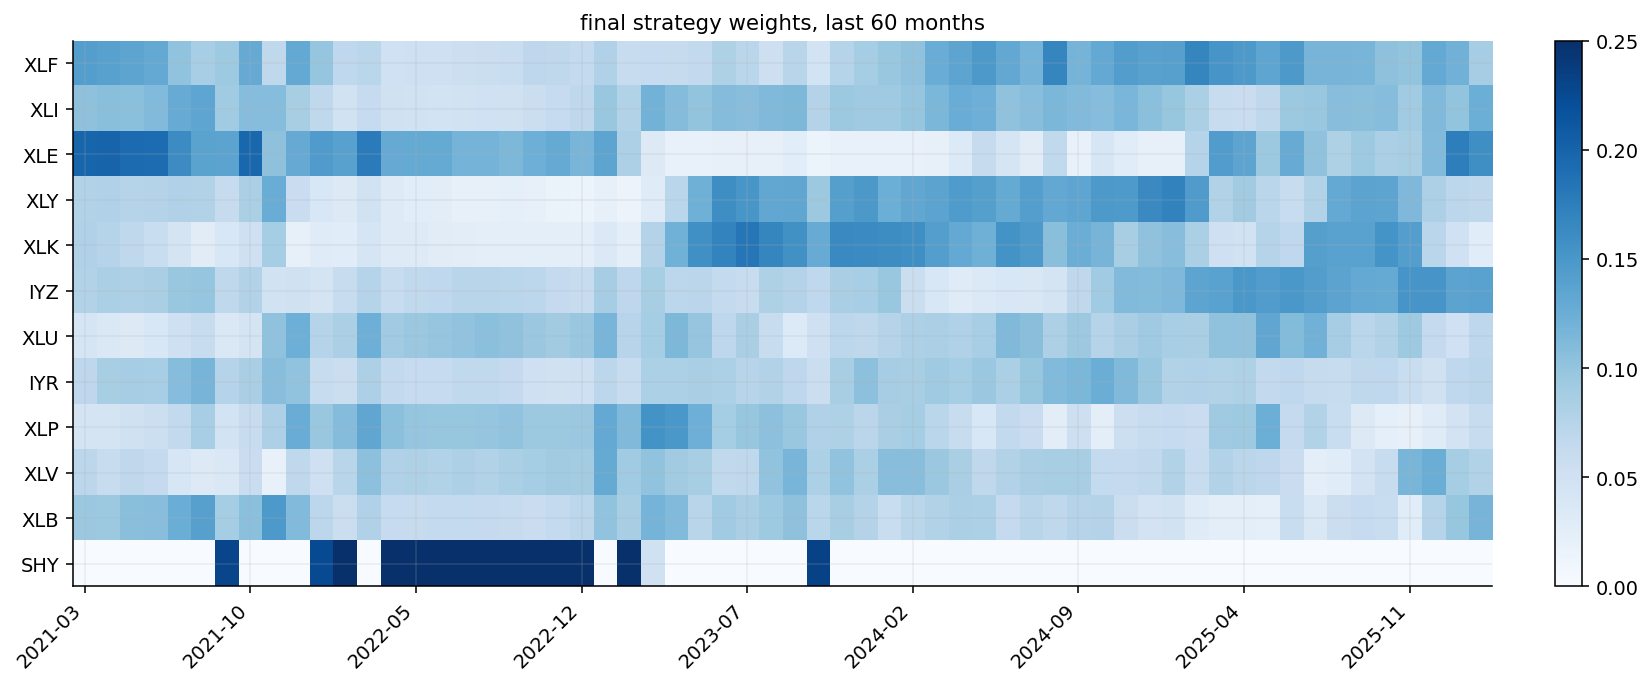

In [31]:
latest_weights = pd.concat({name: w.iloc[-1] for name, w in weights.items()}, axis=1).fillna(0.0)
display(latest_weights.loc[latest_weights.abs().sum(axis=1).gt(0)].round(3))

fig, ax = plt.subplots(figsize=(12, 5))
weight_plot = w_final.tail(60).loc[:, w_final.tail(60).mean().sort_values(ascending=False).index].T
im = ax.imshow(weight_plot, cmap="Blues", aspect="auto", vmin=0.0)
ax.set_title("final strategy weights, last 60 months")
ax.set_yticks(range(len(weight_plot.index)))
ax.set_yticklabels(weight_plot.index)
step = max(1, len(weight_plot.columns) // 8)
locs = list(range(0, len(weight_plot.columns), step))
ax.set_xticks(locs)
ax.set_xticklabels([weight_plot.columns[i].strftime("%Y-%m") for i in locs], rotation=45, ha="right")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

In [32]:
w_max = pd.Series(0.25, index=backtest_cols)
w_max[cash_ticker] = 1.0
w_max[benchmark_ticker] = 1.0

results = run_many_weights_backtests(
    weights,
    returns=backtest_returns,
    cost_bps=10,
    w_min=0.0,
    w_max=w_max,
    weight_timing="next_close",
)

summary = build_strategy_summary(results, annualization=12)
trade_summary = build_trade_table(results)

display(summary.round(4))
display(trade_summary[["Avg Turnover", "Total Turnover", "Total Costs", "Cost Drag", "Effective N"]].round(4))

,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Sector Equal Weight,Sector Equal Weight,-,-,0.1252,0.1610,0.8078,-0.2300,0.5442,1.1603,0.0192,1.5399,0.0009,11.0000,0
SPY,SPY,-,-,0.1526,0.1636,0.9413,-0.2393,0.6379,1.4110,0.0062,0.5000,0.0002,1.0000,0
Sector Momentum,Sector Momentum,-,-,0.1217,0.1318,0.9279,-0.1691,0.7200,1.4269,0.1026,8.2059,0.0053,8.9215,0
Factor Score,Factor Score,-,-,0.1232,0.1339,0.9262,-0.1681,0.7330,1.4537,0.1001,8.0051,0.0051,9.0198,0
Factor + Residual,Factor + Residual,-,-,0.1260,0.1333,0.9477,-0.1625,0.7753,1.4909,0.1117,8.9363,0.0057,9.0146,0
Factor + Residual + Trend - Risk,Factor + Residual + Trend - Risk,-,-,0.1262,0.1324,0.9550,-0.1619,0.7794,1.5135,0.1030,8.2403,0.0053,9.0450,0


,Avg Turnover,Total Turnover,Total Costs,Cost Drag,Effective N
Strategy,,,,,
Sector Equal Weight,0.0192,1.5399,0.0020,0.0009,11.0000
SPY,0.0062,0.5000,0.0005,0.0002,1.0000
Sector Momentum,0.1026,8.2059,0.0113,0.0053,8.9215
Factor Score,0.1001,8.0051,0.0111,0.0051,9.0198
Factor + Residual,0.1117,8.9363,0.0126,0.0057,9.0146
Factor + Residual + Trend - Risk,0.1030,8.2403,0.0117,0.0053,9.0450


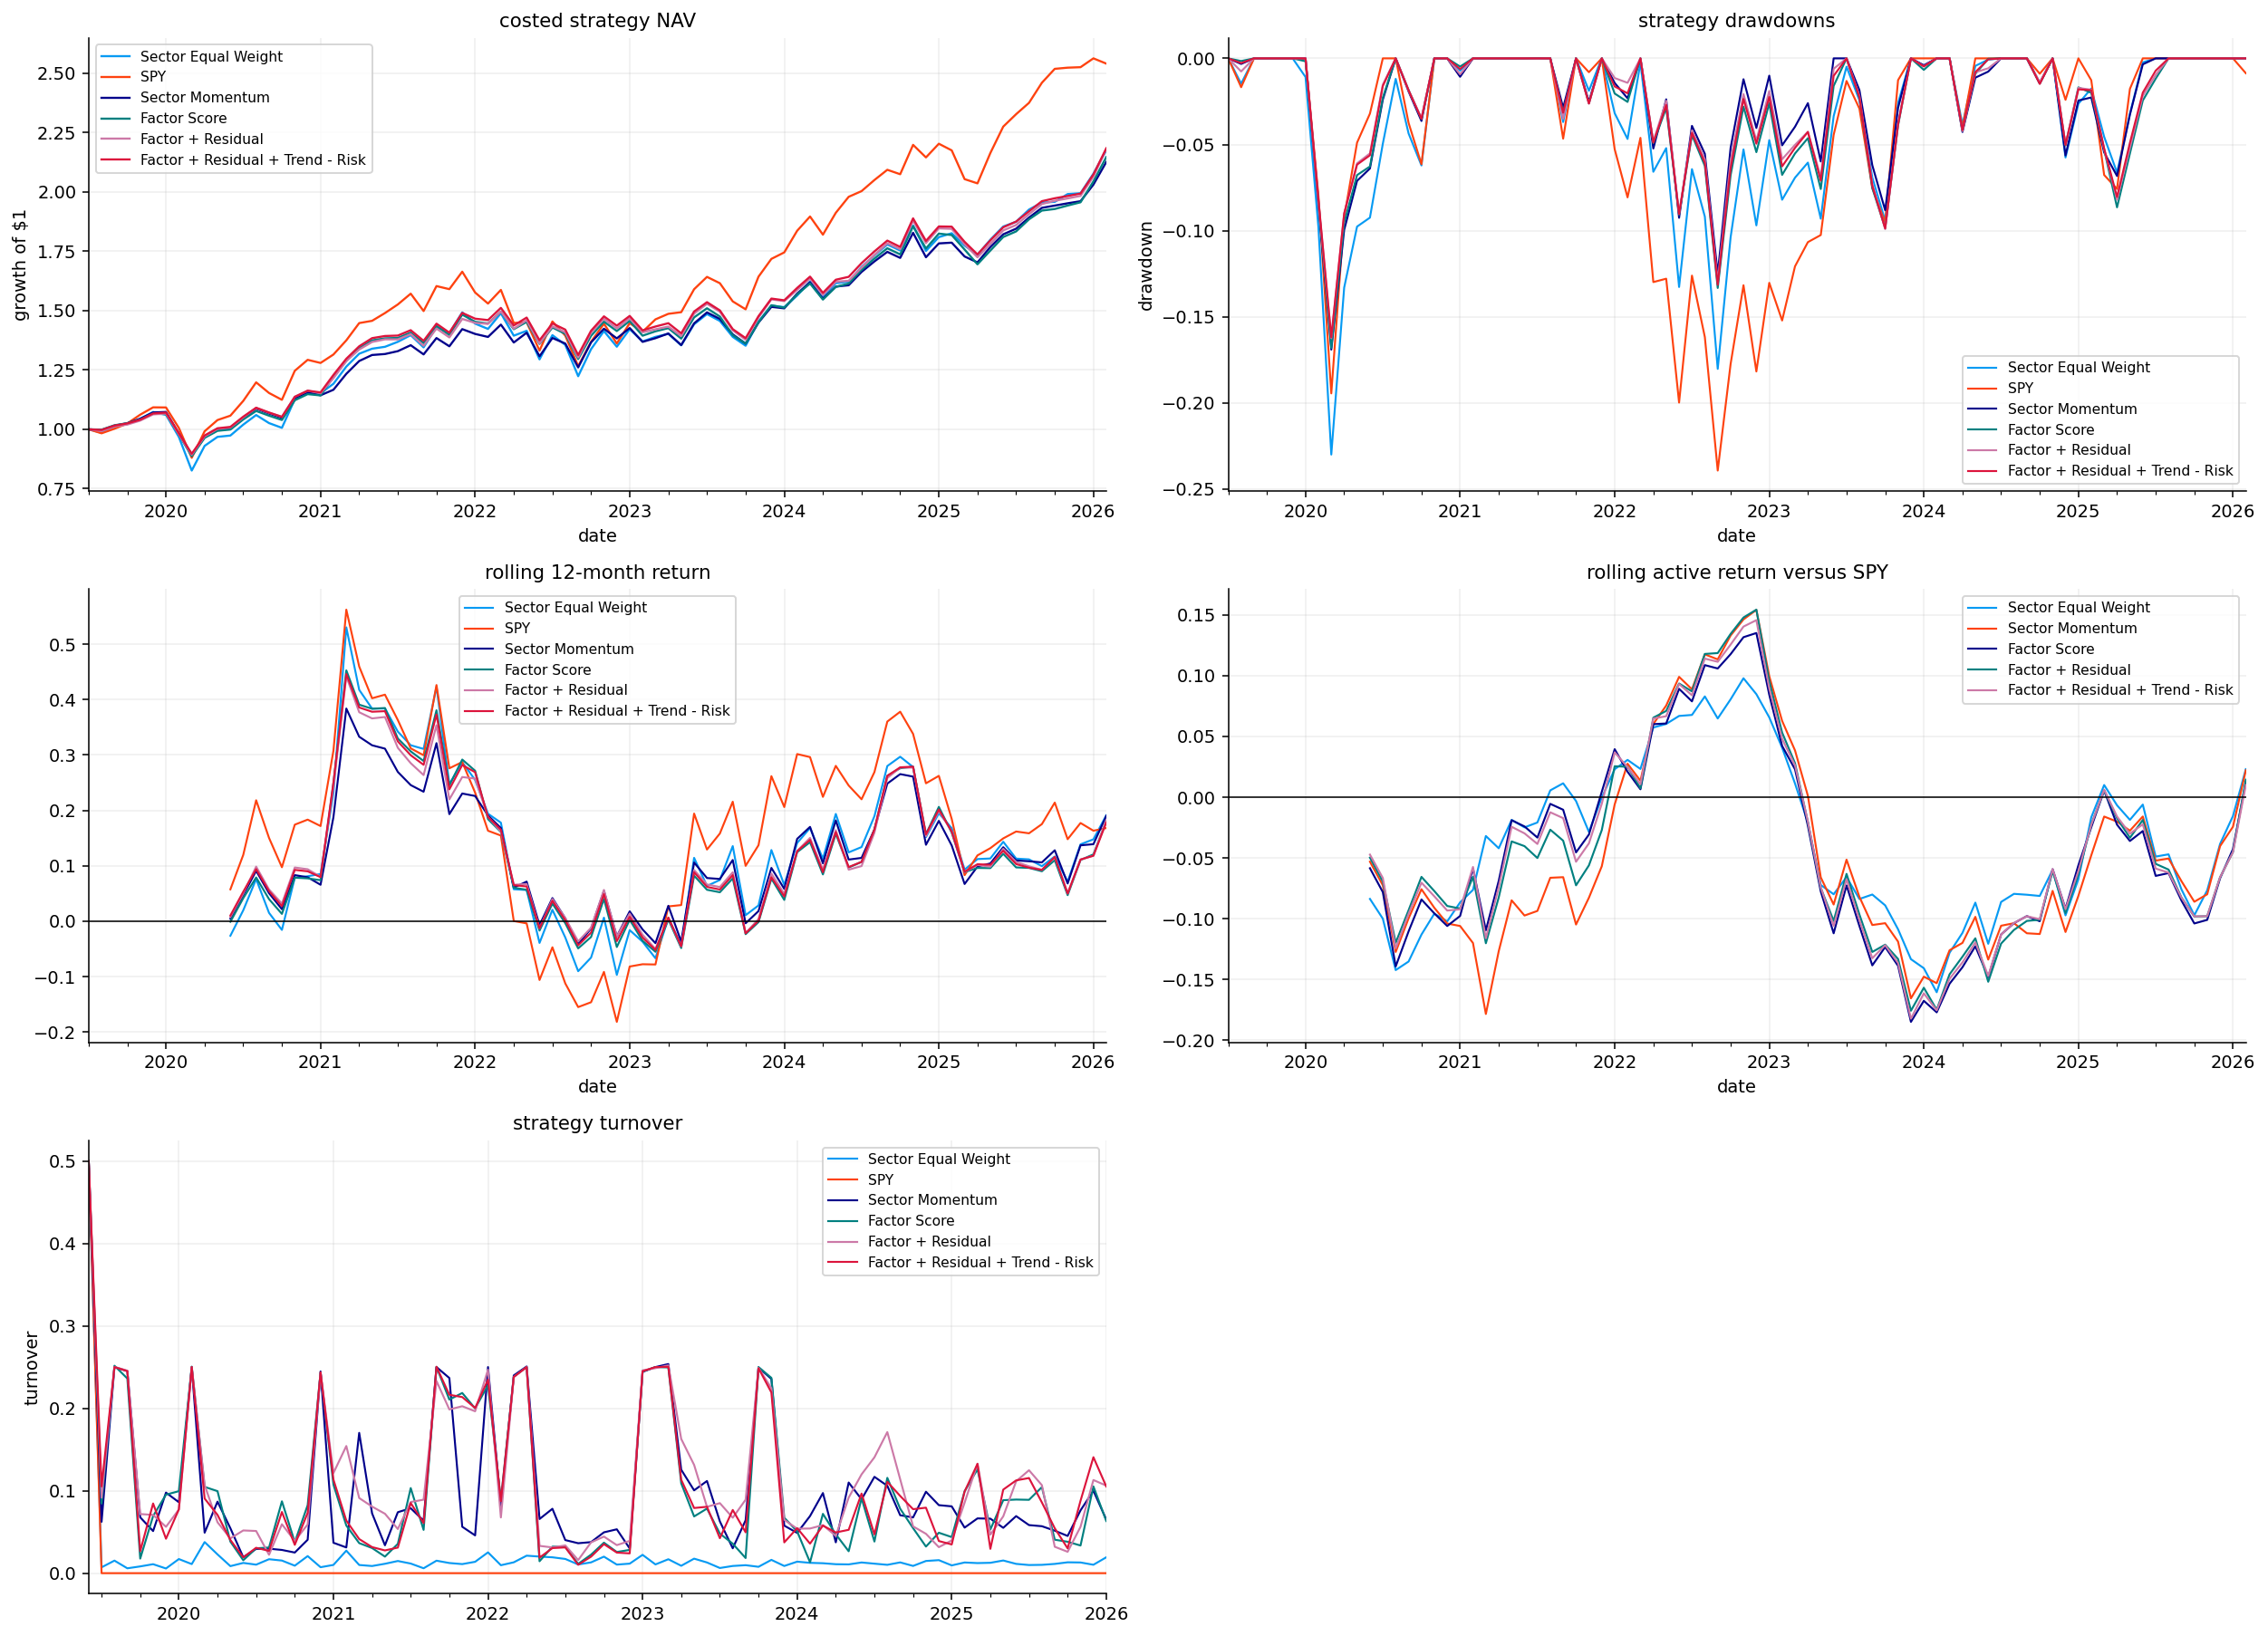

In [33]:
nav = pd.DataFrame({name: result.net_values for name, result in results.items()})
net_returns = pd.DataFrame({name: result.net_returns for name, result in results.items()})
turnover = pd.DataFrame({name: result.turnover for name, result in results.items()})

nav = nav.divide(nav.dropna().iloc[0])
rolling_12 = (1.0 + net_returns).rolling(12).apply(np.prod, raw=True) - 1.0
rolling_active = rolling_12.subtract(rolling_12["SPY"], axis=0)

fig, axes = plt.subplots(3, 2, figsize=(18, 13))
axes = axes.ravel()

nav.plot(ax=axes[0], lw=1.2)
axes[0].set_title("costed strategy NAV")
axes[0].set_ylabel("growth of $1")

nav.apply(calc_drawdown).plot(ax=axes[1], lw=1.1)
axes[1].set_title("strategy drawdowns")
axes[1].set_ylabel("drawdown")

rolling_12.plot(ax=axes[2], lw=1.1)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("rolling 12-month return")

rolling_active.drop(columns="SPY").plot(ax=axes[3], lw=1.1)
axes[3].axhline(0, color="black", lw=0.8)
axes[3].set_title("rolling active return versus SPY")

turnover.plot(ax=axes[4], lw=1.1)
axes[4].set_title("strategy turnover")
axes[4].set_ylabel("turnover")

axes[5].axis("off")
fig.tight_layout()
plt.show()

In [34]:
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "2020 COVID crash": ("2020-02-01", "2020-03-31"),
    "2022 rates shock": ("2022-01-01", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
    "2024-2025": ("2024-01-01", "2025-12-31"),
}

stress_rows = []
for label, (start, end) in stress_windows.items():
    part = net_returns.loc[start:end]
    if part.empty:
        continue
    row = (1.0 + part).prod() - 1.0
    row.name = label
    stress_rows.append(row)

stress_table = pd.DataFrame(stress_rows)
display(stress_table.round(4))

,Sector Equal Weight,SPY,Sector Momentum,Factor Score,Factor + Residual,Factor + Residual + Trend - Risk
2020 COVID crash,-0.2216,-0.1942,-0.1691,-0.1667,-0.1625,-0.1619
2022 rates shock,-0.1039,-0.1774,-0.0393,-0.0602,-0.0392,-0.0505
2023 rebound,0.1284,0.2618,0.0962,0.0768,0.0859,0.0794
2024-2025,0.3113,0.4702,0.2937,0.2849,0.2818,0.2853


In [35]:
final_name = "Factor + Residual + Trend - Risk"
final_weights = results[final_name].weights.reindex(columns=backtest_cols).fillna(0.0)

avg_exposure = final_weights[sector_tickers + [cash_ticker]].mean().sort_values(ascending=False).to_frame("average weight")
contribution = weights[final_name].reindex(backtest_returns.index).shift(1).fillna(0.0).multiply(backtest_returns, axis=0)
sector_contribution = contribution[sector_tickers + [cash_ticker]].sum().sort_values(ascending=False).to_frame("contribution")
best_months = results[final_name].net_returns.sort_values(ascending=False).head(5).to_frame("return")
worst_months = results[final_name].net_returns.sort_values().head(5).to_frame("return")

display(avg_exposure.round(4))
display(sector_contribution.round(4))
display(pd.concat({"best": best_months, "worst": worst_months}, axis=0).round(4))

,average weight
XLK,0.0935
XLF,0.0897
XLY,0.0886
XLI,0.0874
XLU,0.0855
IYZ,0.0839
XLP,0.0820
IYR,0.0796
SHY,0.0788
XLV,0.0776


,contribution
XLE,0.1609
XLK,0.1558
XLF,0.0947
XLY,0.0860
XLI,0.0845
XLB,0.0600
IYZ,0.0573
XLU,0.0504
XLV,0.0481
XLP,0.0356


return
      date              
best  2020-04-30  0.0859
      2020-11-30  0.0801
      2022-10-31  0.0779
      2024-11-30  0.0680
      2023-11-30  0.0670
worst 2020-03-31 -0.0874
      2020-02-29 -0.0817
      2022-09-30 -0.0754
      2022-06-30 -0.0652
      2023-09-30 -0.0527

In [36]:
def portfolio_factor_exposure(weights, beta):
    W = pd.DataFrame(weights).astype(float)
    assets = beta.columns.get_level_values("asset").unique()
    factor_names = beta.columns.get_level_values("factor").unique()
    out = pd.DataFrame(np.nan, index=W.index, columns=factor_names)
    for date in W.index:
        hist = beta.loc[:date].dropna(how="all")
        if hist.empty:
            continue
        b = hist.iloc[-1].unstack("factor")
        w = W.loc[date].reindex(assets).fillna(0.0)
        common = b.index.intersection(w.index)
        if len(common):
            out.loc[date] = w.reindex(common).dot(b.reindex(common))
    return out

In [37]:
latest_date = w_final.dropna(how="all").index[-1]
latest_factor_states = z_factor.loc[latest_date].sort_values(ascending=False).to_frame("state")
latest_sector_scores = pd.concat(
    {
        "factor": s_factor.loc[latest_date],
        "residual": s_resid.loc[latest_date],
        "trend": s_trend.loc[latest_date],
        "risk": s_risk.loc[latest_date],
        "dynamic": s_total.loc[latest_date],
    },
    axis=1,
).sort_values("dynamic", ascending=False)
latest_final_weights = w_final.loc[latest_date].sort_values(ascending=False).to_frame("weight")
final_factor_exposure = portfolio_factor_exposure(w_final, beta)
latest_final_beta = final_factor_exposure.dropna(how="all").iloc[-1].sort_values(ascending=False).to_frame("portfolio beta")
equal_latest = pd.Series(1.0 / len(sector_tickers), index=sector_tickers)
active_vs_equal = w_final.loc[latest_date].reindex(sector_tickers).fillna(0.0).subtract(equal_latest).sort_values(ascending=False).to_frame("active weight")
latest_validation_weight = validation_weights.loc[latest_date].to_frame("validation weight")

display(latest_factor_states.round(3))
display(latest_sector_scores.round(3))
display(latest_validation_weight.round(3))
display(latest_final_weights[latest_final_weights["weight"].gt(0)].round(3))
display(latest_final_beta.round(3))
display(active_vs_equal.round(3))

,state
SMB,2.0000
HML,1.6950
Mkt-RF,0.3830
CMA,0.3360
MOM,0.2340
RMW,-0.9360


,factor,residual,trend,risk,dynamic
XLE,1.8930,-0.2270,0.2590,0.4380,1.0790
IYZ,0.0450,1.8000,1.6430,-0.6470,0.7620
XLI,0.5790,0.0980,1.0010,-0.4900,0.5340
XLB,0.4790,0.6050,-0.0260,-0.0840,0.4210
XLF,1.1950,-2.2990,-1.0100,1.1420,-0.0600
XLV,-0.4210,0.7560,-0.8120,-1.0880,-0.1980
IYR,-0.0070,-0.3000,-1.3940,-0.3420,-0.3250
XLU,-0.7780,0.4590,-0.1220,-0.5800,-0.3560
XLY,-0.2460,-0.8870,-0.0300,0.9850,-0.3670
XLP,-0.7240,0.4380,-1.0710,-1.4020,-0.4970


,validation weight
factor,0.5760
residual,0.2480
trend,0.1760
risk,0.0000


,weight
XLE,0.1580
IYZ,0.1390
XLI,0.1240
XLB,0.1170
XLF,0.0870
XLV,0.0780
IYR,0.0710
XLU,0.0690
XLY,0.0680
XLP,0.0600


,portfolio beta
factor,
Mkt-RF,0.9030
CMA,0.2580
HML,0.2480
RMW,0.1310
SMB,0.0910
MOM,-0.0200


,active weight
XLE,0.0680
IYZ,0.0480
XLI,0.0330
XLB,0.0260
XLF,-0.0040
XLV,-0.0120
IYR,-0.0200
XLU,-0.0220
XLY,-0.0230
XLP,-0.0310


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Country EW,Country EW,-,-,0.1091,0.1763,0.6984,-0.2817,0.3873,1.0760,0.0159,1.2735,0.0007,13.0000,0
EFA,EFA,-,-,0.1044,0.1627,0.7120,-0.2762,0.3779,1.1125,0.0062,0.5000,0.0003,1.0000,0
Country Momentum,Country Momentum,-,-,0.1001,0.1456,0.7532,-0.2443,0.4098,1.2813,0.0895,7.1618,0.0044,10.3739,0
Factor Score,Factor Score,-,-,0.1047,0.1463,0.7824,-0.2496,0.4196,1.3116,0.0790,6.3213,0.0039,10.4781,0
Factor + Residual,Factor + Residual,-,-,0.1069,0.1468,0.7925,-0.2452,0.4362,1.3269,0.0878,7.0270,0.0042,10.4315,0
Dynamic Factor Rotation,Dynamic Factor Rotation,-,-,0.1038,0.1457,0.7765,-0.2422,0.4284,1.3031,0.0851,6.8086,0.0042,10.4709,0


,factor,residual,trend,risk,dynamic
EWH,2.1120,1.5830,0.7910,1.7140,1.7270
EWP,1.1170,-1.2400,2.5560,0.7090,0.6560
EWJ,-0.0030,1.4960,-0.0310,-1.6000,0.4420
EWA,0.8090,-0.0630,-1.0530,0.3720,0.2280
EWC,0.1980,0.1660,0.2130,-0.5450,0.1910
EWS,0.7020,-0.3740,-0.4170,-0.8610,0.1870
EWU,0.1500,0.2700,-0.1460,-1.5620,0.1350
EWN,-0.4230,0.7290,0.6790,0.8200,0.1110
EWD,-0.4590,0.1110,-0.5190,1.5800,-0.2980
EWI,-0.1370,-1.6660,0.8840,0.0430,-0.4210


,validation weight
factor,0.5290
residual,0.3000
trend,0.1710
risk,0.0000


,weight
EWH,0.1590
EWP,0.1080
EWJ,0.0980
EWA,0.0880
EWC,0.0860
EWS,0.0860
EWU,0.0830
EWN,0.0820
EWD,0.0630
EWI,0.0570


,rank_ic,rank_ic_t,hit_rate,n
signal,,,,
factor score,0.0220,0.5410,0.5250,80
residual strength,0.0500,1.4050,0.5470,86
country trend,-0.0200,-0.6180,0.4960,139
dynamic score,0.0390,1.0400,0.5500,80


,top,bottom,top_minus_bottom,hit_rate,n
signal,,,,,
factor score,0.0091,0.0094,-0.0003,0.5000,80
residual strength,0.0127,0.0099,0.0028,0.5000,86
country trend,0.0061,0.0079,-0.0018,0.5108,139
dynamic score,0.0109,0.0101,0.0009,0.4875,80


,,top_return,universe_return,active_return,hit_rate,n
signal,horizon,,,,,
factor score,1,0.0091,0.0100,-0.0009,0.4750,80
residual strength,1,0.0127,0.0111,0.0016,0.5116,86
country trend,1,0.0061,0.0070,-0.0009,0.5108,139
dynamic score,1,0.0109,0.0100,0.0010,0.5375,80
factor score,3,0.0266,0.0298,-0.0033,0.4615,78
residual strength,3,0.0362,0.0302,0.0060,0.6190,84
country trend,3,0.0170,0.0203,-0.0033,0.4599,137
dynamic score,3,0.0339,0.0298,0.0040,0.5897,78
factor score,6,0.0519,0.0579,-0.0060,0.4400,75


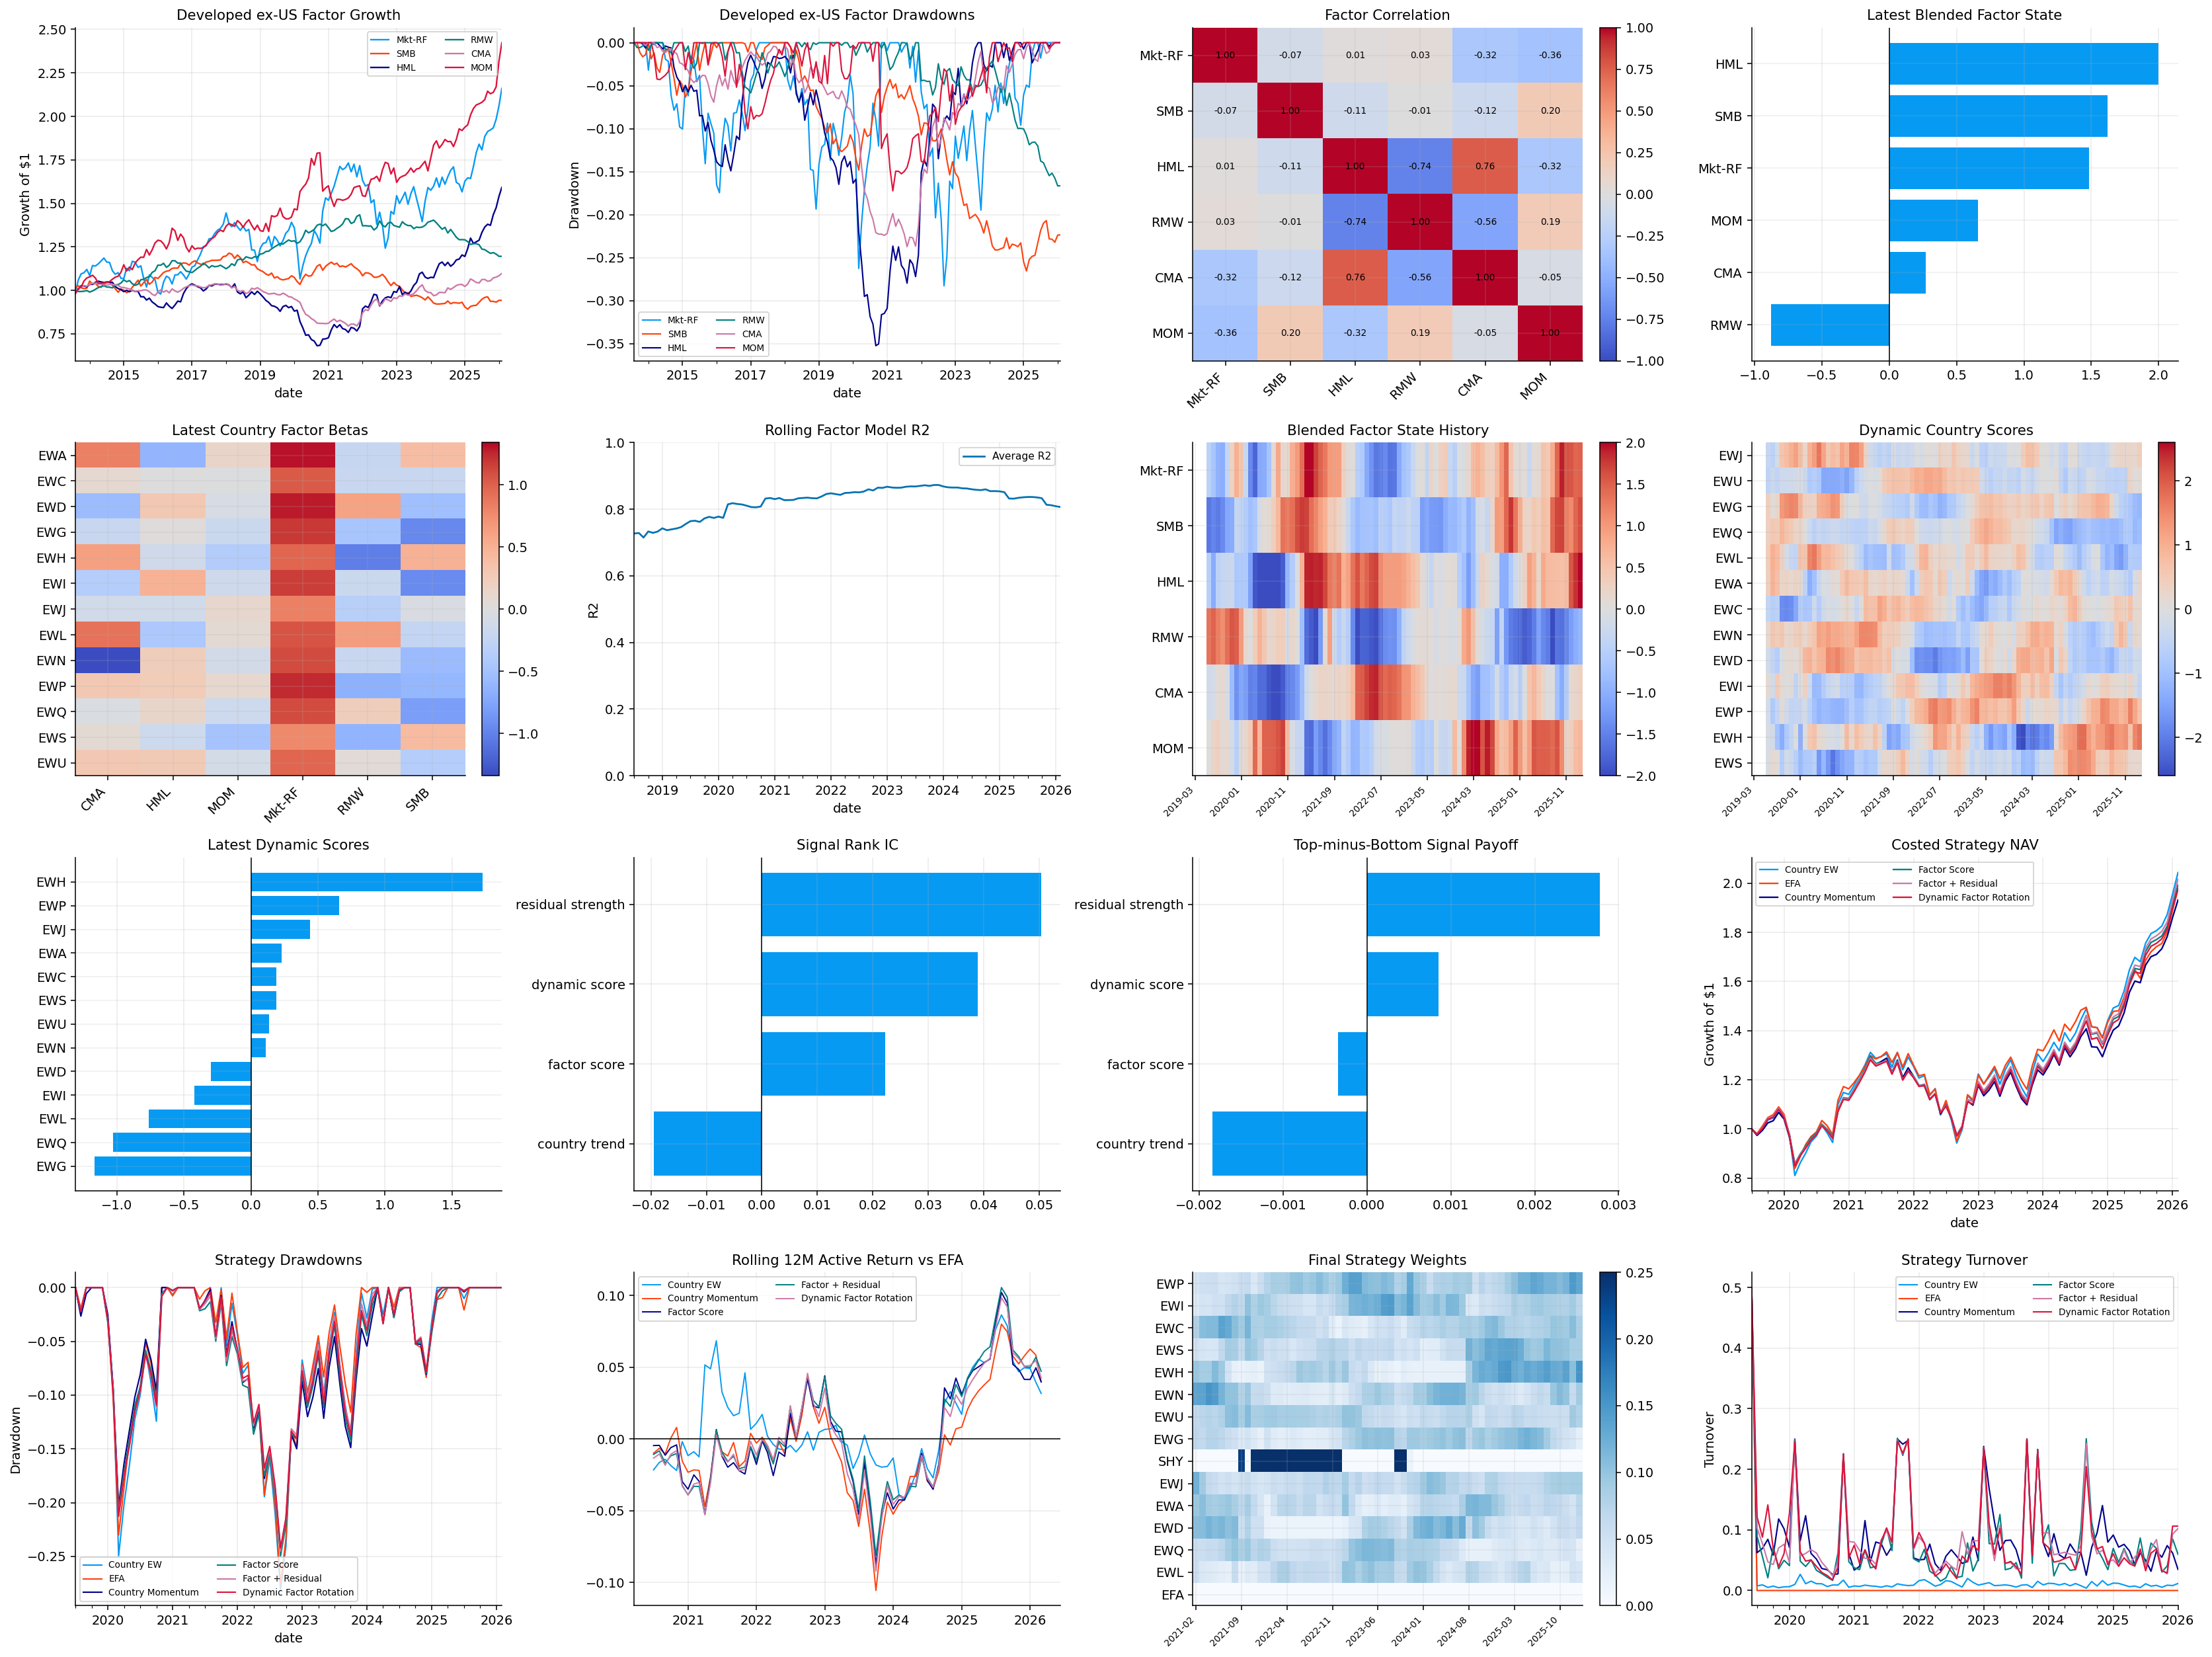

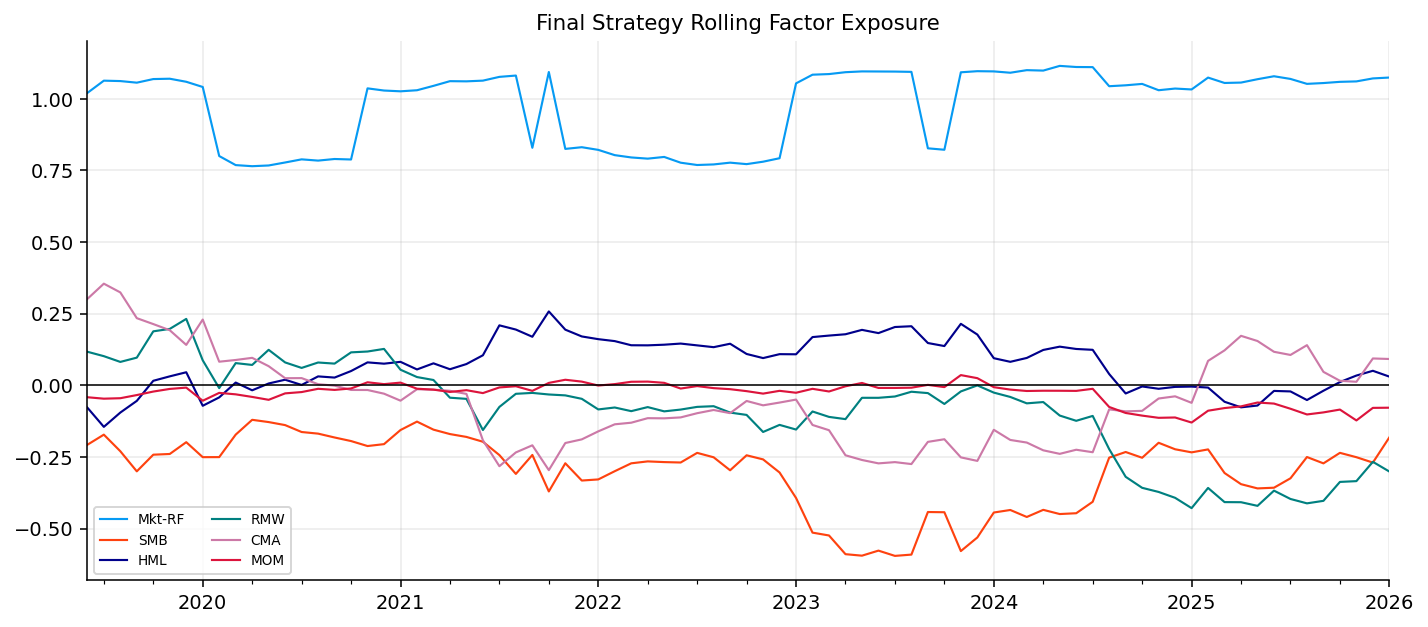

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quantfinlab.dataio.panel import load_yfinance_panel
from quantfinlab.dataio.factors import load_ff_factors, load_ff_momentum
from quantfinlab.portfolio.factors import month_end_prices
from quantfinlab.portfolio.factors import excess_returns
from quantfinlab.portfolio.factors import rolling_factor_fit
from quantfinlab.portfolio.factors import factor_state
from quantfinlab.portfolio.factors import factor_proxy_spreads
from quantfinlab.portfolio.factors import blend_factor_states
from quantfinlab.portfolio.factors import cross_section_z
from quantfinlab.portfolio.factors import factor_scores
from quantfinlab.portfolio.factors import residual_strength
from quantfinlab.portfolio.factors import trend_strength
from quantfinlab.portfolio.factors import risk_penalty
from quantfinlab.portfolio.factors import validation_weighted_score
from quantfinlab.portfolio.factors import equal_weight_schedule
from quantfinlab.portfolio.factors import benchmark_weight_schedule
from quantfinlab.portfolio.factors import soft_active_weights
from quantfinlab.portfolio.factors import rank_ic_table
from quantfinlab.portfolio.factors import top_bottom_table
from quantfinlab.portfolio.factors import signal_decay_table
from quantfinlab.portfolio.factors import portfolio_factor_exposure
from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.portfolio.selection import build_strategy_summary
from quantfinlab.plotting.factors import factor_growth
from quantfinlab.plotting.factors import factor_drawdowns
from quantfinlab.plotting.factors import factor_corr
from quantfinlab.plotting.factors import factor_state_history
from quantfinlab.plotting.factors import latest_factor_state
from quantfinlab.plotting.factors import beta_heatmap
from quantfinlab.plotting.factors import r2_history
from quantfinlab.plotting.factors import score_history
from quantfinlab.plotting.factors import latest_score_bar
from quantfinlab.plotting.factors import signal_ic
from quantfinlab.plotting.factors import top_bottom_payoff
from quantfinlab.plotting.factors import strategy_nav
from quantfinlab.plotting.factors import strategy_drawdowns
from quantfinlab.plotting.factors import rolling_active_return
from quantfinlab.plotting.factors import weight_history
from quantfinlab.plotting.factors import turnover_history
from quantfinlab.plotting.factors import factor_exposure


data_path = Path("../data")
etf_path = data_path / "ETF_data.csv"

country_tickers = [
    "EWJ", "EWU", "EWG", "EWQ", "EWL",
    "EWA", "EWC", "EWN", "EWD", "EWI",
    "EWP", "EWH", "EWS",
]

cash_ticker = "SHY"
benchmark_ticker = "EFA"
factor_proxy_tickers = ["SPY", "IWD", "IWF", "VLUE", "IWM", "RSP", "MTUM", "QUAL", "USMV"]
strategy_tickers = country_tickers + [cash_ticker, benchmark_ticker]
load_tickers = list(dict.fromkeys(strategy_tickers + factor_proxy_tickers))

prices = load_yfinance_panel(
    etf_path,
    fields=("close",),
    tickers=load_tickers,
    start="2003-01-01",
)["close"].ffill(limit=3)

monthly_prices = month_end_prices(prices)
monthly_returns = monthly_prices.pct_change().dropna()

ff5 = load_ff_factors(
    data_path / "Developed_ex_US_5_Factors.csv",
    columns=["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"],
)

mom = load_ff_momentum(
    data_path / "Developed_ex_US_MOM_Factor.csv",
    name="MOM",
)

factors = ff5.drop(columns="RF").join(mom, how="inner")
rf = ff5["RF"].reindex(factors.index)
factor_cols = factors.columns.tolist()

country_returns = monthly_returns[country_tickers]
cash_returns = monthly_returns[[cash_ticker]]
benchmark_returns = monthly_returns[[benchmark_ticker]]

common_dates = country_returns.index.intersection(cash_returns.index)
common_dates = common_dates.intersection(benchmark_returns.index)
common_dates = common_dates.intersection(factors.dropna(subset=factor_cols).index)
common_dates = common_dates.intersection(rf.index)

country_returns = country_returns.loc[common_dates]
cash_returns = cash_returns.loc[common_dates]
benchmark_returns = benchmark_returns.loc[common_dates]
factors = factors.loc[common_dates, factor_cols]
rf = rf.loc[common_dates]

country_excess = excess_returns(country_returns, rf)

alpha, beta, r2, eps = rolling_factor_fit(
    country_excess,
    factors,
    window=60,
)

z_academic = factor_state(
    factors,
    short_window=6,
    long_window=12,
    vol_window=36,
    skip=1,
    clip=2.0,
)

proxy_spreads = factor_proxy_spreads(
    monthly_returns,
    benchmark_ticker="SPY",
    cash_ticker=cash_ticker,
).reindex(common_dates)

z_tradable = factor_state(
    proxy_spreads,
    short_window=6,
    long_window=12,
    vol_window=36,
    skip=1,
    clip=2.0,
)

z_factor = blend_factor_states(
    z_academic,
    z_tradable,
    academic_weight=0.70,
    disagreement_scale=0.50,
)

s_factor = factor_scores(beta, z_factor)
s_factor = cross_section_z(s_factor)

s_resid = residual_strength(eps, window=6)
s_resid = cross_section_z(s_resid)

s_trend = trend_strength(country_returns, window=12, skip=1)
s_trend = cross_section_z(s_trend)

raw_risk = risk_penalty(country_returns, vol_window=36, drawdown_window=12)
s_risk = cross_section_z(raw_risk)

future_returns = country_returns.shift(-1)

s_total, validation_weights = validation_weighted_score(
    {
        "factor": s_factor,
        "residual": s_resid,
        "trend": s_trend,
    },
    future_returns,
    risk=s_risk,
    window=72,
    min_periods=36,
    top_n=3,
    risk_weight=0.20,
    base_weights={"factor": 0.60, "residual": 0.25, "trend": 0.15},
    validation_strength=0.50,
    max_component_weights={"residual": 0.30, "trend": 0.25},
)

ic = rank_ic_table(
    {
        "factor score": s_factor,
        "residual strength": s_resid,
        "country trend": s_trend,
        "dynamic score": s_total,
    },
    future_returns,
)

spread = top_bottom_table(
    {
        "factor score": s_factor,
        "residual strength": s_resid,
        "country trend": s_trend,
        "dynamic score": s_total,
    },
    future_returns,
    top_n=3,
    bottom_n=3,
)

decay = signal_decay_table(
    {
        "factor score": s_factor,
        "residual strength": s_resid,
        "country trend": s_trend,
        "dynamic score": s_total,
    },
    country_returns,
    horizons=(1, 3, 6),
    top_n=3,
)

score_dates = s_total.dropna(how="all").index
backtest_dates = monthly_returns.index.intersection(common_dates)
backtest_dates = backtest_dates[backtest_dates >= score_dates.min()]
backtest_returns = monthly_returns[strategy_tickers].loc[backtest_dates]

w_equal = equal_weight_schedule(country_returns).reindex(backtest_dates)
w_efa = benchmark_weight_schedule(monthly_returns[strategy_tickers], benchmark_ticker).reindex(backtest_dates)

w_mom = soft_active_weights(
    s_trend,
    country_returns,
    cash_returns[cash_ticker],
    risk_score=raw_risk,
    active_budget=0.35,
    min_weight=0.02,
    max_weight=0.25,
    turnover_limit=0.25,
    cash_ticker=cash_ticker,
).reindex(backtest_dates)

w_factor = soft_active_weights(
    s_factor,
    country_returns,
    cash_returns[cash_ticker],
    risk_score=raw_risk,
    active_budget=0.35,
    min_weight=0.02,
    max_weight=0.25,
    turnover_limit=0.25,
    cash_ticker=cash_ticker,
).reindex(backtest_dates)

w_factor_resid = soft_active_weights(
    0.60 * s_factor + 0.40 * s_resid,
    country_returns,
    cash_returns[cash_ticker],
    risk_score=raw_risk,
    active_budget=0.35,
    min_weight=0.02,
    max_weight=0.25,
    turnover_limit=0.25,
    cash_ticker=cash_ticker,
).reindex(backtest_dates)

w_final = soft_active_weights(
    s_total,
    country_returns,
    cash_returns[cash_ticker],
    risk_score=raw_risk,
    active_budget=0.35,
    min_weight=0.02,
    max_weight=0.25,
    turnover_limit=0.25,
    cash_ticker=cash_ticker,
).reindex(backtest_dates)

weights = {
    "Country EW": w_equal,
    "EFA": w_efa,
    "Country Momentum": w_mom,
    "Factor Score": w_factor,
    "Factor + Residual": w_factor_resid,
    "Dynamic Factor Rotation": w_final,
}

weights = {name: w.reindex(index=backtest_dates, columns=backtest_returns.columns).fillna(0.0) for name, w in weights.items()}

w_max = pd.Series(0.25, index=backtest_returns.columns)
w_max[cash_ticker] = 1.0
w_max[benchmark_ticker] = 1.0

results = run_many_weights_backtests(
    weights,
    returns=backtest_returns,
    cost_bps=10,
    w_min=0.0,
    w_max=w_max,
    weight_timing="next_close",
)

summary = build_strategy_summary(results, annualization=12)
display(summary.round(4))

latest_date = s_total.dropna(how="all").index[-1]
latest_scores = pd.concat(
    {
        "factor": s_factor.loc[latest_date],
        "residual": s_resid.loc[latest_date],
        "trend": s_trend.loc[latest_date],
        "risk": s_risk.loc[latest_date],
        "dynamic": s_total.loc[latest_date],
    },
    axis=1,
).sort_values("dynamic", ascending=False)

latest_weights = w_final.loc[latest_date].sort_values(ascending=False).to_frame("weight")
latest_validation_weight = validation_weights.loc[latest_date].to_frame("validation weight")

port_beta = portfolio_factor_exposure(
    results["Dynamic Factor Rotation"].weights,
    beta,
)

display(latest_scores.round(3))
display(latest_validation_weight.round(3))
display(latest_weights[latest_weights["weight"].gt(0)].round(3))
display(ic.round(3))
display(spread.round(4))
display(decay.round(4))

fig, axes = plt.subplots(4, 4, figsize=(24, 18))
axes = axes.ravel()

factor_growth(axes[0], factors, title="Developed ex-US Factor Growth")
factor_drawdowns(axes[1], factors, title="Developed ex-US Factor Drawdowns")
factor_corr(axes[2], factors, title="Factor Correlation")
latest_factor_state(axes[3], z_factor, title="Latest Blended Factor State")

beta_heatmap(axes[4], beta, date=beta.index[-1], title="Latest Country Factor Betas")
r2_history(axes[5], r2, title="Rolling Factor Model R2")
factor_state_history(axes[6], z_factor, title="Blended Factor State History")
score_history(axes[7], s_total, title="Dynamic Country Scores")

latest_score_bar(axes[8], latest_scores["dynamic"], title="Latest Dynamic Scores")
signal_ic(axes[9], ic, title="Signal Rank IC")
top_bottom_payoff(axes[10], spread, title="Top-minus-Bottom Signal Payoff")
strategy_nav(axes[11], results, title="Costed Strategy NAV")

strategy_drawdowns(axes[12], results, title="Strategy Drawdowns")
rolling_active_return(axes[13], results, benchmark="EFA", window=12, title="Rolling 12M Active Return vs EFA")
weight_history(axes[14], results["Dynamic Factor Rotation"].weights, title="Final Strategy Weights")
turnover_history(axes[15], results, title="Strategy Turnover")

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
factor_exposure(
    ax,
    port_beta,
    title="Final Strategy Rolling Factor Exposure",
)
plt.show()